# Gamma Spec Calibration v8 — better peak-shape fits (fix residual patterns)

This version fixes the obvious *structured residual* problem by:

- using an **adaptive fit window** (based on measured peak width) instead of a fixed ±60 channels;
- fitting **non-Gaussian NaI photopeaks** with an **exponentially modified Gaussian (EMG)** + **quadratic background** when it beats a plain Gaussian (AIC selection);
- saving per-day calibration-curve overlays and a CSV summary table.

Run top-to-bottom.

In [1]:
# -----------------------------
# IMPORTS
# -----------------------------
from __future__ import annotations
from dataclasses import dataclass
from pathlib import Path
from datetime import datetime
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import find_peaks, savgol_filter, peak_widths
from scipy.optimize import curve_fit
from scipy.special import erfc


In [2]:
# -----------------------------
# CONFIG (EDIT ME)
# -----------------------------
ROOT_CAL = Path("processed_data/calibration")  # folder of converted calibration CSVs
BG_DEFAULT = Path("processed_data/calibration/background_550PM_feb26_213PM_mar3.csv")  # or None

CFG = {
    # Peak finding
    "smooth_window": 21,
    "smooth_poly": 3,
    "min_distance": 20,
    "prominence_frac": 0.005,
    "max_peaks_global": 40,

    # Fit windowing (adaptive)
    "fit_half_window_min": 25,
    "fit_half_window_max": 140,
    "fit_half_window_scale": 1.8,  # half-window ~ scale * (FWHM/2)
    "fit_min_points": 35,

    # Shape model
    "peak_model": "auto",          # "gauss" | "emg" | "auto"
    "background_poly_order": 2,    # 1 (linear) or 2 (quadratic)

    # Parameter bounds
    "sigma_bounds": (2.0, 220.0),
    "tau_bounds": (1.0, 400.0),    # EMG tail scale (channels)

    # Fit QA
    "min_amp_snr": 2.0,
    "sys_frac": 0.015,             # smaller than before; we now fit a better shape
    "require_positive_amp": True,

    # DEBUG
    "debug_peak_fits": True,
    "debug_max_peak_plots": 12,
    "debug_plot_failed_fits": True,
}


In [3]:
# -----------------------------
# KNOWN GAMMA LINES (keV)
# -----------------------------
Cs_spectra = np.array([31.8, 37.3, 661.657])
Ba_spectra = np.array([53.15, 79.60, 80.998, 160.605, 223.246, 276.397, 302.851, 356.005, 383.851])
Co60_spectra = np.array([1173.228, 1332.494])
Na_spectra = np.array([511.006, 1274.537])
Co57_spectra = np.array([14.4136, 122.060, 136.471, 570.1, 692.4])


In [4]:
# -----------------------------
# DATA STRUCTURES
# -----------------------------
@dataclass
class Spectrum:
    path: Path
    channel: np.ndarray
    counts: np.ndarray
    meta: dict

    @property
    def dt_seconds(self) -> float:
        return float(self.meta.get("elapsed_real_time_s") or self.meta.get("dt_seconds") or np.nan)

@dataclass
class NetSpectrum:
    path_sig: Path
    channel: np.ndarray
    net_counts: np.ndarray
    net_sigma: np.ndarray
    meta_sig: dict
    meta_bg: dict | None

    @property
    def dt_sig(self) -> float:
        return float(self.meta_sig.get("elapsed_real_time_s") or self.meta_sig.get("dt_seconds") or np.nan)

@dataclass
class PeakFit:
    mu: float
    mu_err: float
    sigma: float
    sigma_err: float
    amp: float
    amp_err: float
    chi2: float
    ndf: int
    success: bool
    reason: str = ""
    model: str = ""
    popt: np.ndarray | None = None

    @property
    def chi2_ndf(self) -> float:
        return self.chi2 / self.ndf if self.ndf > 0 else np.inf

@dataclass
class CalibrationFit:
    model: str
    params: np.ndarray
    cov: np.ndarray
    chi2: float
    ndf: int
    used_points: int

    @property
    def chi2_ndf(self) -> float:
        return self.chi2 / self.ndf if self.ndf > 0 else np.inf


In [5]:
# -----------------------------
# CSV HEADER PARSING (ROBUST)
# -----------------------------
def _parse_time_seconds(token: str) -> float | None:
    if token is None:
        return None
    s = str(token).strip()
    if not s:
        return None
    try:
        if re.fullmatch(r"[+-]?(\d+\.?\d*|\d*\.?\d+)", s):
            return float(s)
    except Exception:
        pass
    m = re.match(r"^(\d+)\s*:\s*(\d+)\s*:\s*(\d+)\s*$", s)
    if m:
        h, mi, se = map(int, m.groups())
        return float(h*3600 + mi*60 + se)
    return None

def _parse_datetime_fuzzy(s: str) -> datetime | None:
    s = str(s).strip()
    for fmt in [
        "%A, %B %d, %Y, %H:%M:%S",
        "%B %d, %Y, %H:%M:%S",
        "%Y-%m-%d %H:%M:%S",
    ]:
        try:
            return datetime.strptime(s, fmt)
        except ValueError:
            pass
    return None

def read_spectrum_csv(path: Path) -> Spectrum:
    lines = path.read_text(errors="ignore").splitlines()
    meta: dict = {"path": str(path)}
    col_header_idx = None

    for i, raw in enumerate(lines):
        if not raw.strip():
            continue
        parts = [p.strip() for p in raw.split(",")]

        if parts and parts[0].lower().startswith("start time"):
            dt_str = ", ".join(parts[1:]).strip()
            meta["start_time"] = _parse_datetime_fuzzy(dt_str)
            continue

        if parts and parts[0].lower().startswith("end time"):
            dt_str = ", ".join(parts[1:]).strip()
            meta["end_time"] = _parse_datetime_fuzzy(dt_str)
            continue

        for j, field in enumerate(parts):
            f = field.lower()
            if "elapsed real time" in f:
                val = parts[j+1].strip() if j+1 < len(parts) else ""
                sec = _parse_time_seconds(val)
                if sec is not None:
                    meta["elapsed_real_time_s"] = sec
                break
            if "elapsed live time" in f:
                val = parts[j+1].strip() if j+1 < len(parts) else ""
                sec = _parse_time_seconds(val)
                if sec is not None:
                    meta["elapsed_live_time_s"] = sec
                break

        if raw.strip().lower().startswith("channel") and ("counts" in raw.lower()):
            col_header_idx = i
            break

    if meta.get("elapsed_real_time_s") is None:
        st = meta.get("start_time")
        et = meta.get("end_time")
        if isinstance(st, datetime) and isinstance(et, datetime):
            meta["dt_seconds"] = (et - st).total_seconds()

    if col_header_idx is None:
        df = pd.read_csv(path)
    else:
        df = pd.read_csv(path, skiprows=col_header_idx)

    df.columns = [c.strip().lower() for c in df.columns]
    if "channel" not in df.columns:
        df = df.rename(columns={df.columns[0]: "channel"})
    if "counts" not in df.columns:
        df = df.rename(columns={df.columns[-1]: "counts"})

    df = df[["channel", "counts"]].copy()
    df["channel"] = pd.to_numeric(df["channel"], errors="coerce")
    df["counts"] = pd.to_numeric(df["counts"], errors="coerce")
    df = df.dropna()

    return Spectrum(
        path=path,
        channel=df["channel"].to_numpy(dtype=float),
        counts=df["counts"].to_numpy(dtype=float),
        meta=meta,
    )


In [6]:
# -----------------------------
# BACKGROUND SUBTRACTION
# -----------------------------
def subtract_background_counts(sig: Spectrum, bg: Spectrum) -> NetSpectrum:
    if sig.channel.shape != bg.channel.shape or not np.allclose(sig.channel, bg.channel):
        raise ValueError("Signal and background channels don't match.")
    t_sig = sig.dt_seconds
    t_bg = bg.dt_seconds
    if not np.isfinite(t_sig) or not np.isfinite(t_bg) or t_sig <= 0 or t_bg <= 0:
        raise ValueError(f"Bad dt (t_sig={t_sig}, t_bg={t_bg}). Check elapsed time parsing.")
    scale = t_sig / t_bg
    net = sig.counts - scale * bg.counts
    var = sig.counts + (scale**2) * bg.counts
    sigma = np.sqrt(np.clip(var, 0, np.inf))
    return NetSpectrum(sig.path, sig.channel.copy(), net, sigma, sig.meta, bg.meta)

def spectrum_with_errors(spec: Spectrum):
    x = spec.channel
    y = spec.counts
    yerr = np.sqrt(np.clip(y, 0, np.inf))
    return x, y, yerr


In [7]:
# -----------------------------
# PEAK MODELS
# -----------------------------
def _poly_bg(x, *p):
    # p = (c0, c1) or (c0, c1, c2)
    if len(p) == 2:
        c0, c1 = p
        return c0 + c1*x
    if len(p) == 3:
        c0, c1, c2 = p
        return c0 + c1*x + c2*x*x
    raise ValueError("background poly order must be 1 or 2")

def gauss_plus_bg(x, A, mu, sig, *bg):
    return A * np.exp(-0.5*((x-mu)/sig)**2) + _poly_bg(x, *bg)

def emg_right(x, A, mu, sig, tau):
    # Exponentially modified Gaussian with right tail (to +x)
    # Standard form uses erfc; safe for curve_fit.
    # Note: A is peak area-ish scale (not exactly amplitude).
    lam = 1.0 / tau
    arg = (lam*sig*sig - (x-mu)) / (np.sqrt(2.0)*sig)
    return 0.5*A*lam*np.exp(0.5*(lam*sig)**2 - lam*(x-mu)) * erfc(arg)

def emg_left(x, A, mu, sig, tau):
    # Tail to -x (low-energy tail in many NaI photopeaks)
    # Mirror trick: left-tail EMG is right-tail EMG in mirrored coordinate.
    return emg_right(-x, A, -mu, sig, tau)

def emg_plus_bg(x, A, mu, sig, tau, side, *bg):
    peak = emg_left(x, A, mu, sig, tau) if side < 0 else emg_right(x, A, mu, sig, tau)
    return peak + _poly_bg(x, *bg)


In [8]:
# -----------------------------
# PEAK FINDING + FITTING
# -----------------------------
def _smooth(y: np.ndarray, window: int, poly: int) -> np.ndarray:
    window = int(window)
    if window < 5:
        return y.copy()
    if window % 2 == 0:
        window += 1
    if window >= len(y):
        window = max(5, (len(y)//2)*2 - 1)
    return savgol_filter(y, window_length=window, polyorder=min(poly, window-2))

def find_peaks_global(y: np.ndarray, cfg: dict) -> tuple[np.ndarray, dict]:
    ys = _smooth(y, cfg["smooth_window"], cfg["smooth_poly"])
    prom = float(cfg["prominence_frac"]) * float(np.nanmax(ys) if np.nanmax(ys) > 0 else 1.0)
    peaks, props = find_peaks(ys, prominence=prom, distance=cfg["min_distance"])
    if len(peaks) == 0:
        return peaks, props
    order = np.argsort(props["prominences"])[::-1]
    peaks = peaks[order]
    props = {k: np.asarray(v)[order] for k, v in props.items()}
    peaks = peaks[: cfg["max_peaks_global"]]
    props = {k: v[: cfg["max_peaks_global"]] for k, v in props.items()}
    return peaks, props

def _adaptive_half_window(x, y, idx, props, k, cfg):
    # Use peak width estimate at half prominence from smoothed signal,
    # then inflate to cover tails but not the whole Compton shoulder.
    ys = _smooth(y, cfg["smooth_window"], cfg["smooth_poly"])
    try:
        results = peak_widths(ys, [idx], rel_height=0.5)
        width = float(results[0][0])  # in samples/channels
    except Exception:
        width = 2.0 * cfg["fit_half_window_min"]

    half = int(max(cfg["fit_half_window_min"], min(cfg["fit_half_window_max"], cfg["fit_half_window_scale"] * 0.5 * width)))
    return half

def _inflate_errors(yw, ew, sys_frac):
    ew = np.where(ew > 0, ew, 1.0)
    if sys_frac and sys_frac > 0:
        ew = np.sqrt(ew**2 + (sys_frac*np.maximum(np.abs(yw), 1.0))**2)
    return ew

def _aic(chi2, n, k):
    # AIC for Gaussian errors: chi2 + 2k (up to additive constant)
    return chi2 + 2*k

def fit_peak(x, y, yerr, idx0, cfg, allow_negative_amp: bool) -> PeakFit:
    idx0 = int(idx0)
    # window
    peaks, props = np.array([idx0]), {}
    half = cfg["fit_half_window_max"]  # placeholder; caller will pass adaptive half
    # (caller now supplies half via cfg override)
    half = int(cfg.get("_half_override", cfg["fit_half_window_max"]))
    L = max(0, idx0 - half)
    R = min(len(x)-1, idx0 + half)
    if R - L + 1 < cfg["fit_min_points"]:
        return PeakFit(0,0,0,0,0,0,np.inf,0,False,"window too small","")

    xw = x[L:R+1]
    yw = y[L:R+1]
    ew = _inflate_errors(yw, yerr[L:R+1], float(cfg.get("sys_frac", 0.0)))

    mu0 = float(x[idx0])
    edge = max(5, len(yw)//8)
    baseline0 = float(np.median(np.r_[yw[:edge], yw[-edge:]]))
    amp0 = float(np.max(yw) - baseline0)
    if not np.isfinite(amp0) or abs(amp0) < 1e-9:
        amp0 = float(np.max(np.abs(yw)) if np.max(np.abs(yw)) > 0 else 1.0)

    # quick sigma0 from moment around the local max neighborhood
    sig0 = 12.0

    sig_lo, sig_hi = cfg["sigma_bounds"]
    tau_lo, tau_hi = cfg["tau_bounds"]
    order = int(cfg.get("background_poly_order", 1))
    bg0 = [baseline0, 0.0] if order == 1 else [baseline0, 0.0, 0.0]

    # amplitude bounds
    if allow_negative_amp:
        A_lo, A_hi = (-np.inf, np.inf)
        require_pos = False
    else:
        require_pos = bool(cfg.get("require_positive_amp", True))
        A_lo, A_hi = ((0.0, np.inf) if require_pos else (-np.inf, np.inf))

    # ---- candidates
    candidates = []

    # Gaussian candidate
    if cfg["peak_model"] in ("gauss", "auto"):
        p0 = [amp0, mu0, sig0] + bg0
        bounds_lo = [A_lo, xw.min(), sig_lo] + ([-np.inf]*len(bg0))
        bounds_hi = [A_hi, xw.max(), sig_hi] + ([np.inf]*len(bg0))
        try:
            popt, pcov = curve_fit(
                lambda xx, A, mu, sig, *bg: gauss_plus_bg(xx, A, mu, sig, *bg),
                xw, yw, p0=p0, sigma=ew, absolute_sigma=True,
                bounds=(bounds_lo, bounds_hi), maxfev=20000
            )
            model = gauss_plus_bg(xw, *popt)
            resid = (yw - model)/ew
            chi2 = float(np.sum(resid**2))
            ndf = int(len(xw) - len(popt))
            perr = np.sqrt(np.diag(pcov))
            A, mu, sig = popt[0], popt[1], popt[2]
            Aerr, muerr, sigerr = perr[0], perr[1], perr[2]
            candidates.append(("gauss", popt, pcov, chi2, ndf, (A, Aerr, mu, muerr, sig, sigerr)))
        except Exception:
            pass

    # EMG candidates (left + right tail) + poly background
    if cfg["peak_model"] in ("emg", "auto"):
        for side in (-1.0, +1.0):
            p0 = [max(amp0, 1.0), mu0, sig0, 40.0, side] + bg0
            # side is fixed in fit by not making it a parameter (we encode it in function closure)
            p0 = [max(amp0, 1.0), mu0, sig0, 40.0] + bg0
            bounds_lo = [max(0.0, A_lo) if require_pos else A_lo, xw.min(), sig_lo, tau_lo] + ([-np.inf]*len(bg0))
            bounds_hi = [A_hi, xw.max(), sig_hi, tau_hi] + ([np.inf]*len(bg0))
            try:
                popt, pcov = curve_fit(
                    lambda xx, A, mu, sig, tau, *bg: emg_plus_bg(xx, A, mu, sig, tau, side, *bg),
                    xw, yw, p0=p0, sigma=ew, absolute_sigma=True,
                    bounds=(bounds_lo, bounds_hi), maxfev=40000
                )
                model = emg_plus_bg(xw, *popt[:4], side, *popt[4:])
                resid = (yw - model)/ew
                chi2 = float(np.sum(resid**2))
                ndf = int(len(xw) - len(popt))
                perr = np.sqrt(np.diag(pcov))
                A, mu, sig, tau = popt[0], popt[1], popt[2], popt[3]
                Aerr, muerr, sigerr = perr[0], perr[1], perr[2]
                candidates.append((f"emg{'L' if side<0 else 'R'}", popt, pcov, chi2, ndf, (A, Aerr, mu, muerr, sig, sigerr)))
            except Exception:
                pass

    if not candidates:
        return PeakFit(0,0,0,0,0,0,np.inf,0,False,"fit failed (all models)","")

    # pick best by AIC (penalize extra params mildly)
    best = None
    best_score = np.inf
    for name, popt, pcov, chi2, ndf, pack in candidates:
        k = len(popt)
        score = _aic(chi2, len(xw), k)
        if score < best_score:
            best_score = score
            best = (name, popt, pcov, chi2, ndf, pack)

    name, popt, pcov, chi2, ndf, pack = best
    A, Aerr, mu, muerr, sig, sigerr = pack

    if not (xw.min() < mu < xw.max()):
        return PeakFit(mu, muerr, sig, sigerr, A, Aerr, chi2, ndf, False, "mu outside window", name)
    if require_pos and A <= 0:
        return PeakFit(mu, muerr, sig, sigerr, A, Aerr, chi2, ndf, False, "amp<=0", name)
    if ndf <= 0:
        return PeakFit(mu, muerr, sig, sigerr, A, Aerr, chi2, ndf, False, "ndf<=0", name)
    if np.isfinite(Aerr) and Aerr > 0:
        snr = abs(A)/Aerr
        if snr < cfg["min_amp_snr"]:
            return PeakFit(mu, muerr, sig, sigerr, A, Aerr, chi2, ndf, False, f"amp snr low ({snr:.2f})", name)

    return PeakFit(mu, muerr, sig, sigerr, A, Aerr, chi2, ndf, True, "", name, popt=np.asarray(popt))

def _eval_model(name, xw, popt, order):
    if name == "gauss":
        return gauss_plus_bg(xw, *popt)
    if name == "emgL":
        return emg_plus_bg(xw, *popt[:4], -1.0, *popt[4:])
    if name == "emgR":
        return emg_plus_bg(xw, *popt[:4], +1.0, *popt[4:])
    raise ValueError(name)


def _model_from_peakfit(pf: PeakFit, xw: np.ndarray) -> np.ndarray | None:
    if (not pf.success) or (pf.popt is None):
        return None
    try:
        if pf.model == "gauss":
            return gauss_plus_bg(xw, *pf.popt)
        if pf.model == "emgL":
            return emg_plus_bg(xw, *pf.popt[:4], -1.0, *pf.popt[4:])
        if pf.model == "emgR":
            return emg_plus_bg(xw, *pf.popt[:4], +1.0, *pf.popt[4:])
    except Exception:
        return None
    return None

def plot_peak_fit_window(xw, yw, ew, pf: PeakFit, title: str):
    model_y = _model_from_peakfit(pf, np.asarray(xw, dtype=float))

    plt.figure()
    plt.errorbar(xw, yw, yerr=ew, fmt=".", markersize=3)
    if pf.success and model_y is not None:
        plt.plot(xw, model_y, linewidth=2)
        plt.axvline(pf.mu, linestyle="--", linewidth=1)
        plt.title(f"{title}\n{pf.model}  mu={pf.mu:.2f}±{pf.mu_err:.2f}, chi2/ndf={pf.chi2_ndf:.2f}")
    else:
        plt.title(f"{title}\nFAILED: {pf.reason}")
    plt.xlabel("ADC Channel")
    plt.ylabel("Counts")
    plt.grid(True, alpha=0.3)
    plt.show()

    if pf.success and model_y is not None:
        plt.figure()
        resid = (yw - model_y) / ew
        plt.axhline(0, linewidth=1)
        plt.plot(xw, resid, ".", markersize=3)
        plt.xlabel("ADC Channel")
        plt.ylabel("Residuals (sigma)")
        plt.title("Fit residuals (pattern check)")
        plt.grid(True, alpha=0.3)
        plt.show()


def discover_peak_list(x, y, yerr, cfg, *, allow_negative_amp: bool, label: str):
    peak_idxs, props = find_peaks_global(y, cfg)
    fits = []
    plotted = 0
    ys = _smooth(y, cfg["smooth_window"], cfg["smooth_poly"])

    for k, idx in enumerate(peak_idxs):
        idx = int(idx)
        half = _adaptive_half_window(x, y, idx, props, k, cfg)
        cfg_local = dict(cfg)
        cfg_local["_half_override"] = half

        pf = fit_peak(x, y, yerr, idx, cfg_local, allow_negative_amp=allow_negative_amp)

        if cfg.get("debug_peak_fits", False) and plotted < cfg.get("debug_max_peak_plots", 12):
            if pf.success or cfg.get("debug_plot_failed_fits", True):
                L = max(0, idx - half)
                R = min(len(x)-1, idx + half)
                xw = x[L:R+1]
                yw = y[L:R+1]
                ew = _inflate_errors(yw, yerr[L:R+1], float(cfg.get("sys_frac", 0.0)))
                plot_peak_fit_window(xw, yw, ew, pf, title=f"{label}: peak#{k} idx={idx} half={half}")

                plotted += 1

        if pf.success:
            fits.append(pf)

    fits.sort(key=lambda p: p.mu)
    return fits

def plot_spectrum(x, y, title="", peaks=None):
    plt.figure()
    plt.plot(x, y, linewidth=1)
    if peaks:
        for p in peaks:
            plt.axvline(p.mu, linestyle="--", linewidth=1)
    plt.xlabel("ADC Channel")
    plt.ylabel("Counts")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()


In [9]:
# -----------------------------
# CALIBRATION FIT
# -----------------------------
def cal_linear(ch, m, b):
    return m*ch + b

def fit_calibration_from_pairs(ch, E, ch_err=None, model="linear") -> CalibrationFit:
    ch = np.asarray(ch, dtype=float)
    E = np.asarray(E, dtype=float)

    if model != "linear":
        raise ValueError("This notebook currently uses linear calibration (per your baseline workflow).")

    if ch_err is not None:
        popt0, _ = curve_fit(cal_linear, ch, E)
        m0, _ = popt0
        Eerr = np.clip(abs(m0)*np.asarray(ch_err, dtype=float), 1e-12, np.inf)
        popt, pcov = curve_fit(cal_linear, ch, E, sigma=Eerr, absolute_sigma=True)
        pred = cal_linear(ch, *popt)
        chi2 = float(np.sum(((E - pred)/Eerr)**2))
        ndf = int(len(ch)-len(popt))
        return CalibrationFit("linear", np.array(popt), pcov, chi2, ndf, len(ch))

    popt, pcov = curve_fit(cal_linear, ch, E)
    pred = cal_linear(ch, *popt)
    chi2 = float(np.sum((E - pred)**2))
    ndf = int(len(ch)-len(popt))
    return CalibrationFit("linear", np.array(popt), pcov, chi2, ndf, len(ch))

def plot_calibration(ch, E, cal: CalibrationFit, title="Calibration"):
    plt.figure()
    plt.scatter(ch, E)
    xx = np.linspace(min(ch), max(ch), 500)
    plt.plot(xx, cal_linear(xx, *cal.params), linewidth=2)
    plt.xlabel("ADC Channel")
    plt.ylabel("Energy (keV)")
    plt.title(f"{title} ({cal.model})")
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure()
    pred = cal_linear(np.array(ch), *cal.params)
    res = np.array(E) - pred
    plt.axhline(0, linewidth=1)
    plt.scatter(ch, res)
    plt.xlabel("ADC Channel")
    plt.ylabel("Residual (keV)")
    plt.title(f"{title} residuals")
    plt.grid(True, alpha=0.3)
    plt.show()


In [10]:
# -----------------------------
# FILE SELECTION
# -----------------------------
def list_csvs(root: Path) -> list[Path]:
    return sorted(root.rglob("*.csv"))

def select_isotope(paths: list[Path], *, date_folder: str, preamp_folder: str, isotope: str) -> Path | None:
    iso = isotope.lower()
    for p in paths:
        s = p.as_posix().lower()
        if f"/{date_folder.lower()}/" not in s:
            continue
        if f"/{preamp_folder.lower()}/" not in s:
            continue
        name = p.name.lower()
        if name.startswith(iso + "_") or name.startswith(iso + "-") or name.startswith(iso):
            return p
    return None


In [11]:
# -----------------------------
# BASELINE BUILDERS
# -----------------------------
def identify_co60_doublet(peaks: list[PeakFit]) -> tuple[PeakFit, PeakFit] | None:
    if len(peaks) < 2:
        return None
    # take the two highest-energy-ish large peaks
    peaks_sorted = sorted(peaks, key=lambda p: abs(p.amp), reverse=True)[:min(12, len(peaks))]
    best = None
    best_score = -np.inf
    for i in range(len(peaks_sorted)):
        for j in range(i+1, len(peaks_sorted)):
            p1, p2 = peaks_sorted[i], peaks_sorted[j]
            d = abs(p2.mu - p1.mu)
            if d < 20:
                continue
            score = (abs(p1.amp) * abs(p2.amp)) / d
            if score > best_score:
                best_score = score
                best = (p1, p2)
    if best is None:
        return None
    return tuple(sorted(best, key=lambda p: p.mu))

def build_baseline_preamp100(co60_path: Path, bg_path: Path | None = None):
    co60 = read_spectrum_csv(co60_path)
    if bg_path is not None:
        bg = read_spectrum_csv(bg_path)
        net = subtract_background_counts(co60, bg)
        x, y, yerr = net.channel, net.net_counts, net.net_sigma
        allow_neg = True
        label = f"Co60 NET preamp100 ({co60_path.name})"
    else:
        x, y, yerr = spectrum_with_errors(co60)
        allow_neg = False
        label = f"Co60 RAW preamp100 ({co60_path.name})"

    peaks = discover_peak_list(x, y, yerr, CFG, allow_negative_amp=allow_neg, label=label)
    plot_spectrum(x, y, title=label, peaks=peaks)

    pair = identify_co60_doublet(peaks)
    if pair is None:
        raise RuntimeError("Could not identify Co-60 doublet. Try lowering prominence_frac.")
    p1173, p1332 = pair
    ch = np.array([p1173.mu, p1332.mu])
    cherr = np.array([p1173.mu_err, p1332.mu_err])
    cal = fit_calibration_from_pairs(ch, Co60_spectra, cherr, model="linear")
    plot_calibration(ch, Co60_spectra, cal, title="Baseline preamp100 (Co60)")
    return cal, {"co60_doublet": (p1173, p1332)}

def build_baseline_preamp0(cs_path: Path, ba_path: Path, bg_path: Path | None = None):
    cs = read_spectrum_csv(cs_path)
    if bg_path is not None:
        bg = read_spectrum_csv(bg_path)
        net = subtract_background_counts(cs, bg)
        x, y, yerr = net.channel, net.net_counts, net.net_sigma
        allow_neg = True
        label = f"Cs NET preamp0 ({cs_path.name})"
    else:
        x, y, yerr = spectrum_with_errors(cs)
        allow_neg = False
        label = f"Cs RAW preamp0 ({cs_path.name})"

    peaks = discover_peak_list(x, y, yerr, CFG, allow_negative_amp=allow_neg, label=label)
    plot_spectrum(x, y, title=label, peaks=peaks)

    if len(peaks) == 0:
        raise RuntimeError("No Cs peaks accepted. Lower prominence_frac or widen fit windows.")
    # choose the strongest peak as 661 keV
    cs661 = max(peaks, key=lambda p: abs(p.amp))

    ba = read_spectrum_csv(ba_path)
    if bg_path is not None:
        bg = read_spectrum_csv(bg_path)
        netb = subtract_background_counts(ba, bg)
        xb, yb, eb = netb.channel, netb.net_counts, netb.net_sigma
        allow_neg_ba = True
        label_ba = f"Ba NET preamp0 ({ba_path.name})"
    else:
        xb, yb, eb = spectrum_with_errors(ba)
        allow_neg_ba = False
        label_ba = f"Ba RAW preamp0 ({ba_path.name})"

    ba_peaks = discover_peak_list(xb, yb, eb, CFG, allow_negative_amp=allow_neg_ba, label=label_ba)
    plot_spectrum(xb, yb, title=label_ba, peaks=ba_peaks)

    if len(ba_peaks) == 0:
        raise RuntimeError("No Ba peaks accepted. Lower prominence_frac.")

    # anchor Ba356 by expected scaling relative to Cs661
    cs_mu = cs661.mu
    candidates = [p for p in ba_peaks if p.mu < cs_mu]
    if not candidates:
        raise RuntimeError("No Ba peak below Cs661; check file selection.")
    target = cs_mu * (356.005 / 661.657)
    ba356 = min(candidates, key=lambda p: abs(p.mu - target))

    ch = np.array([ba356.mu, cs661.mu])
    cherr = np.array([ba356.mu_err, cs661.mu_err])
    E = np.array([356.005, 661.657])
    cal = fit_calibration_from_pairs(ch, E, cherr, model="linear")
    plot_calibration(ch, E, cal, title="Baseline preamp0 (Ba356 + Cs661)")
    return cal, {"cs_661_candidate": cs661, "ba356_candidate": ba356}


In [12]:
# -----------------------------
# DAILY GROUPING + DRIFTED CALIBRATIONS
# -----------------------------
from collections import defaultdict

OUT_DIR = Path("processed_data/calibration_curves")
OUT_DIR.mkdir(parents=True, exist_ok=True)

def _infer_day_from_meta_or_name(spec: Spectrum) -> str:
    st = spec.meta.get("start_time")
    if isinstance(st, datetime):
        return st.date().isoformat()
    name = spec.path.name.lower()
    m = re.search(r"(jan|feb|mar|apr|may|jun|jul|aug|sep|oct|nov|dec)[-_ ]?(\d{1,2})", name)
    if m:
        mon, day = m.group(1), int(m.group(2))
        mon_map = {"jan":1,"feb":2,"mar":3,"apr":4,"may":5,"jun":6,"jul":7,"aug":8,"sep":9,"oct":10,"nov":11,"dec":12}
        return datetime(2026, mon_map[mon], day).date().isoformat()
    return "unknown-day"

def _infer_preamp_from_path(p: Path) -> int | None:
    s = p.as_posix().lower()
    m = re.search(r"preamp[_ ]?(\d+)", s)
    if m:
        return int(m.group(1))
    if "/preamp_0/" in s:
        return 0
    if "/preamp_100/" in s:
        return 100
    return None

def group_daily_files(paths: list[Path]) -> dict[str, dict[int, dict[str, Path]]]:
    groups: dict[str, dict[int, dict[str, Path]]] = defaultdict(lambda: defaultdict(dict))
    daily_paths = [p for p in paths if "/daily/" in p.as_posix().lower()] or paths
    for p in daily_paths:
        name = p.name.lower()
        iso = None
        for cand in ["cs", "co60", "ba", "na", "co57"]:
            if name.startswith(cand):
                iso = cand
                break
        if iso is None:
            continue
        pre = _infer_preamp_from_path(p)
        try:
            spec = read_spectrum_csv(p)
            day = _infer_day_from_meta_or_name(spec)
        except Exception:
            dummy = Spectrum(path=p, channel=np.array([]), counts=np.array([]), meta={})
            day = _infer_day_from_meta_or_name(dummy)
        if pre is None:
            pre = 0 if iso in ["cs","ba","co57"] else 100
        groups[day][pre][iso] = p
    return groups

def linear_map_from_two_points(x1, y1, x2, y2):
    if abs(x2 - x1) < 1e-12:
        raise ValueError("Degenerate points for linear mapping.")
    a = (y2 - y1) / (x2 - x1)
    b = y1 - a*x1
    return a, b

def drifted_calibration_from_baseline_linear(cal_base: CalibrationFit, *, alpha: float, beta: float) -> CalibrationFit:
    m, b = cal_base.params
    m2 = m*alpha
    b2 = m*beta + b
    cov = np.array([[np.nan, np.nan],[np.nan, np.nan]])
    return CalibrationFit("linear", np.array([m2, b2]), cov, chi2=np.nan, ndf=0, used_points=cal_base.used_points)

def plot_daily_calibration_day(day: str, cal0_day: CalibrationFit | None, cal100_day: CalibrationFit | None,
                               cal0_base: CalibrationFit, cal100_base: CalibrationFit):
    plt.figure()
    xx = np.array([0, 1024.0])

    # base
    plt.plot(xx, cal_linear(xx, *cal0_base.params), linestyle="--", label="base preamp0")
    plt.plot(xx, cal_linear(xx, *cal100_base.params), linestyle="--", label="base preamp100")

    if cal0_day is not None:
        plt.plot(xx, cal_linear(xx, *cal0_day.params), label="day preamp0")
    if cal100_day is not None:
        plt.plot(xx, cal_linear(xx, *cal100_day.params), label="day preamp100")

    plt.xlabel("ADC Channel")
    plt.ylabel("Energy (keV)")
    plt.title(f"Calibration curves ({day})")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    out = OUT_DIR / f"calcurves_{day}.png"
    plt.savefig(out, dpi=160)
    plt.show()
    print("Saved:", out)


Found 10 CSVs under processed_data/calibration
bg_path: processed_data/calibration/background_550PM_feb26_213PM_mar3.csv


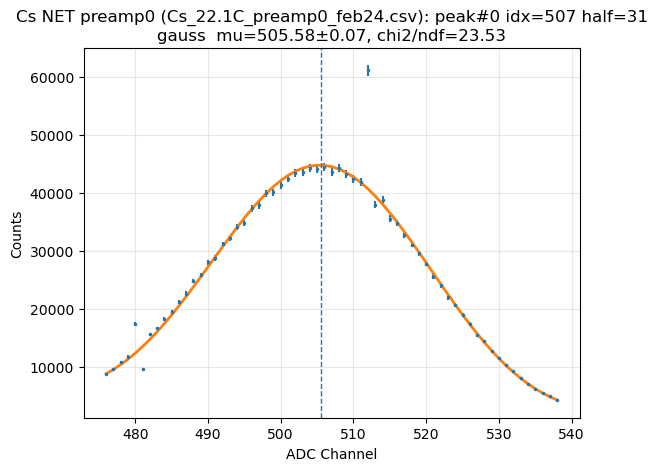

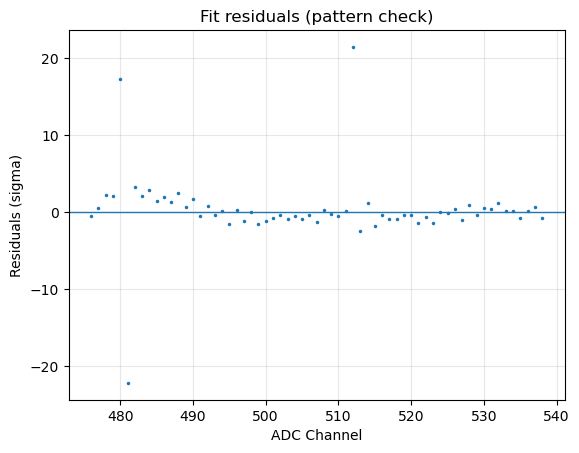

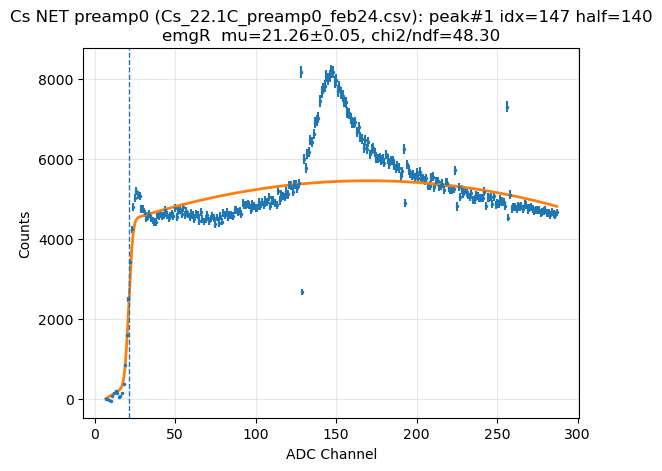

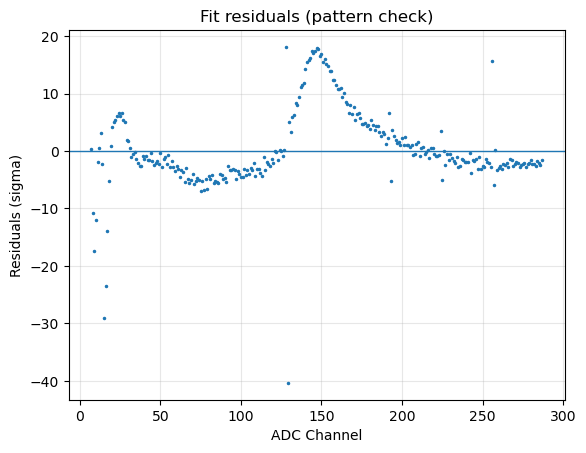

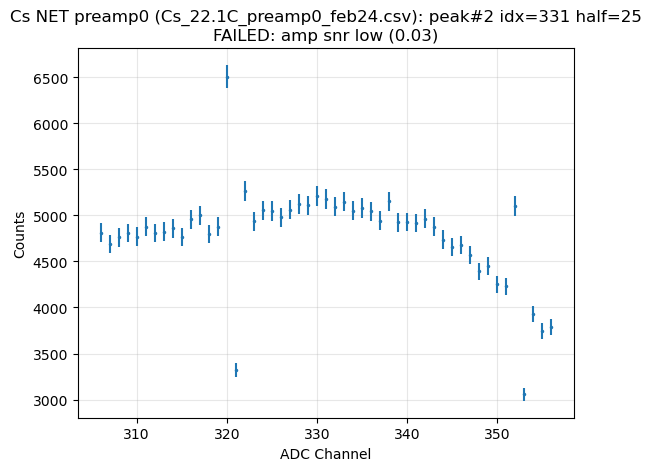

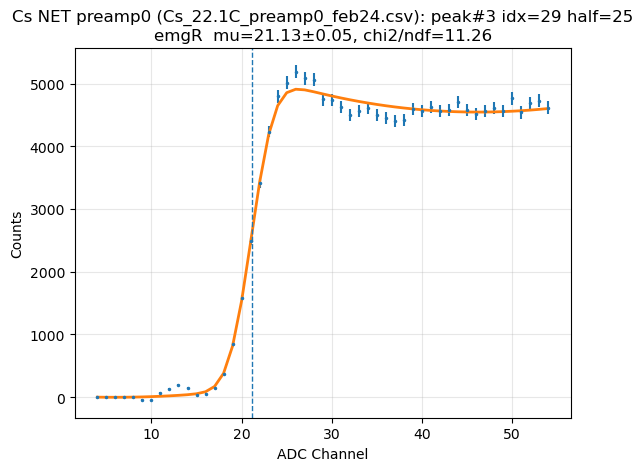

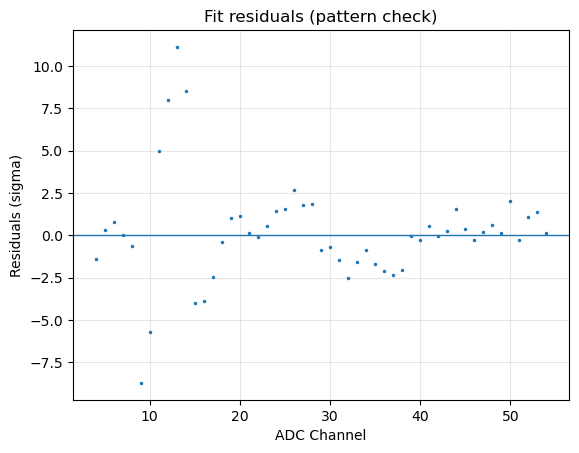

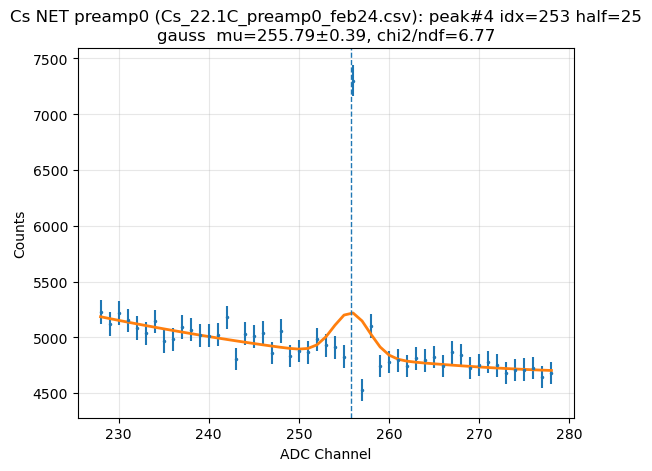

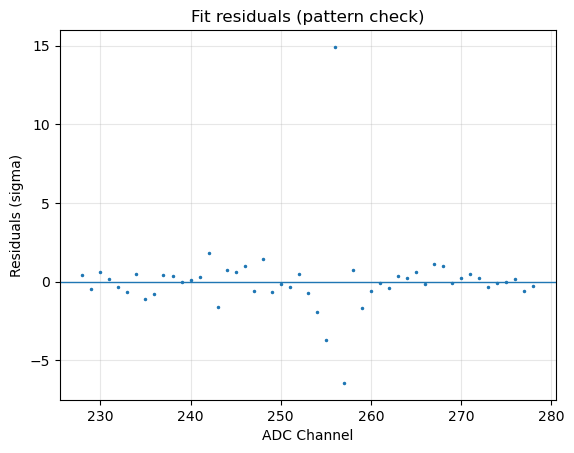

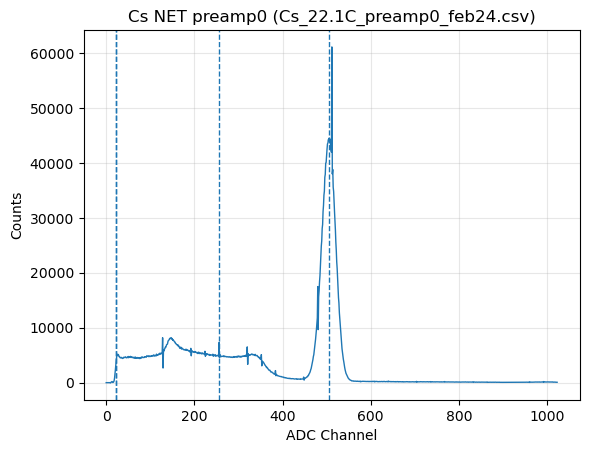

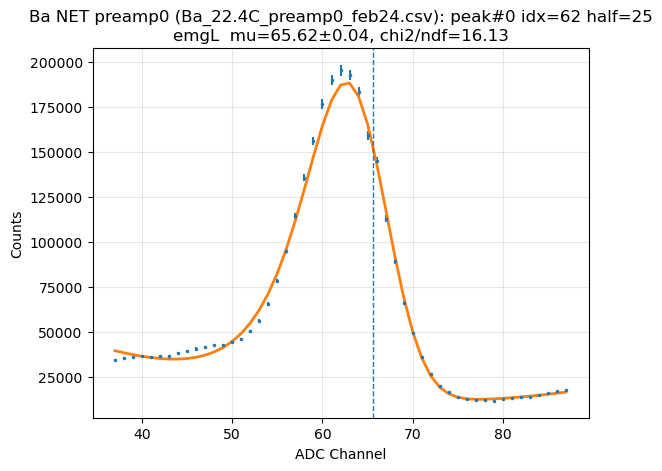

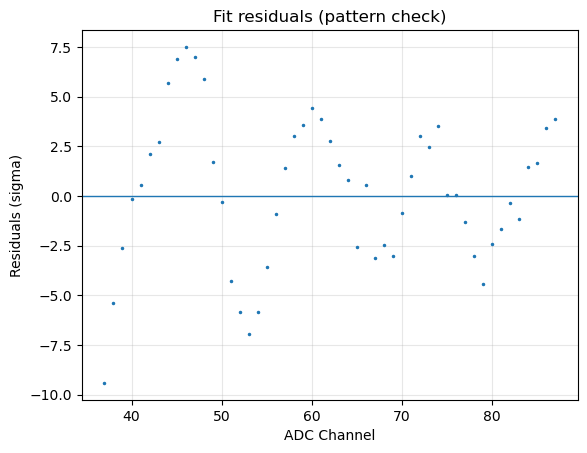

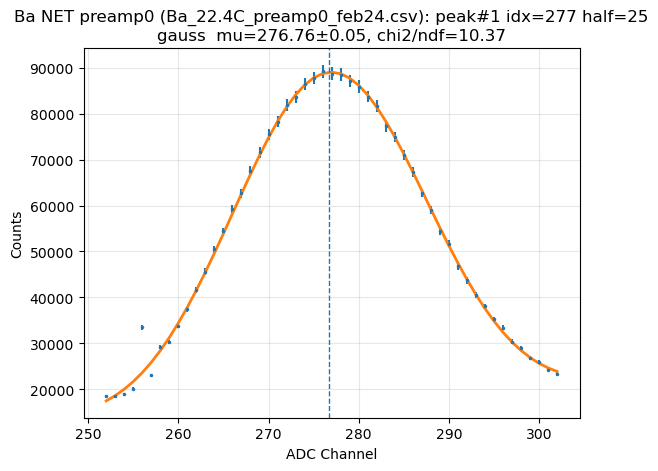

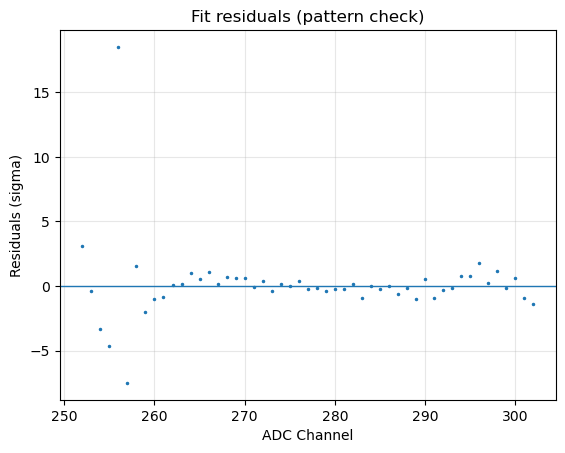

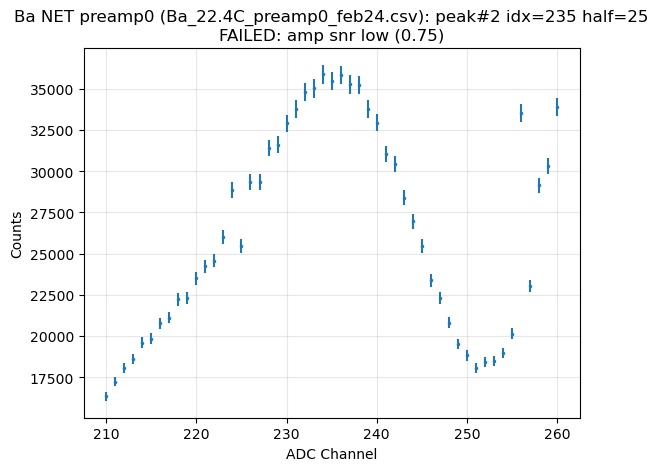

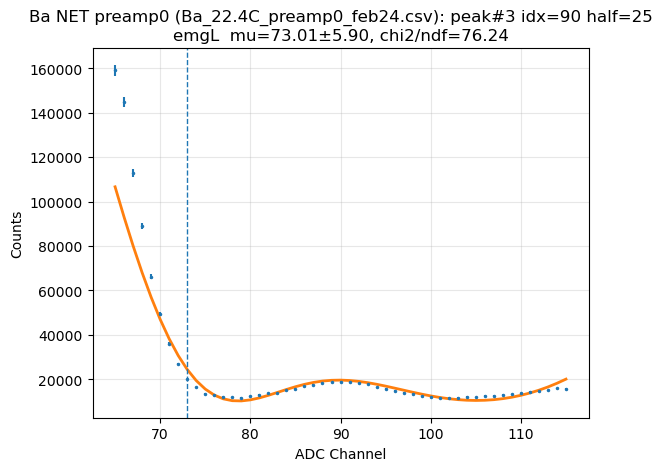

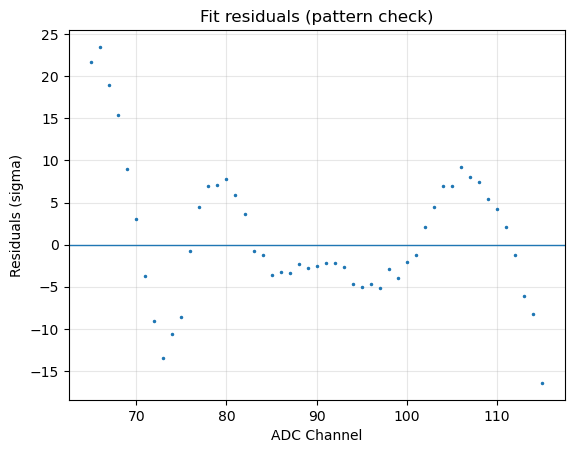

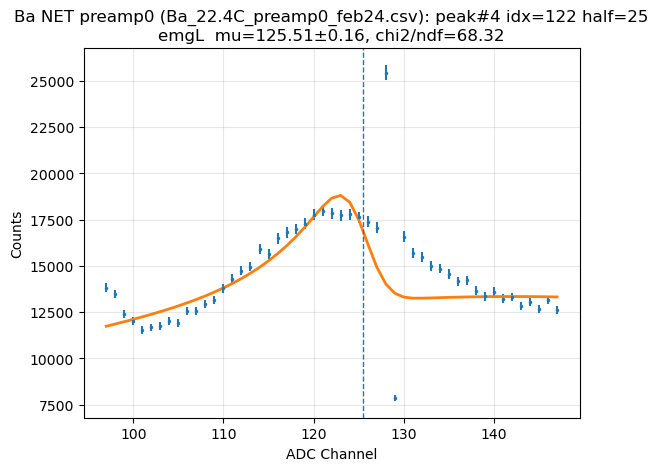

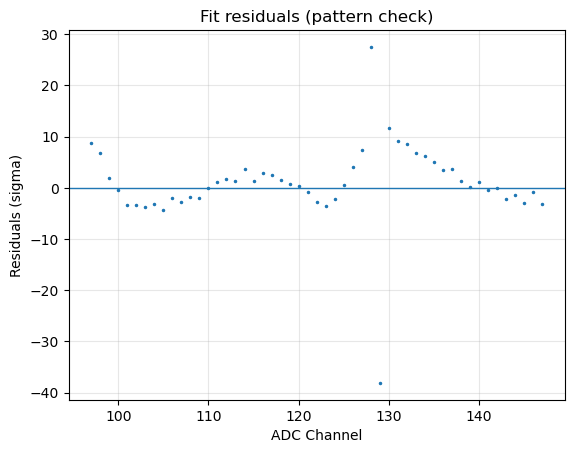

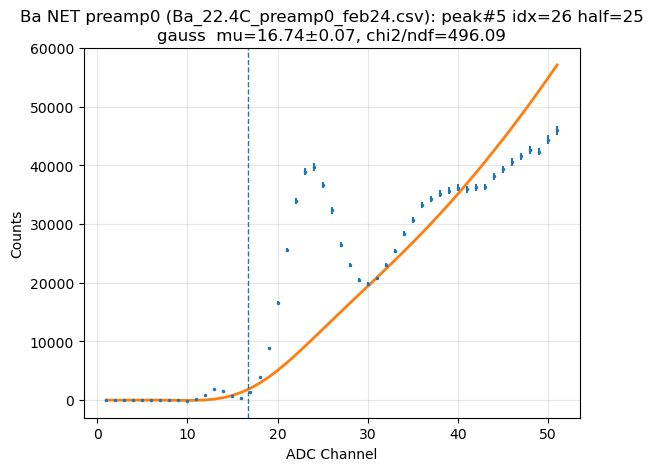

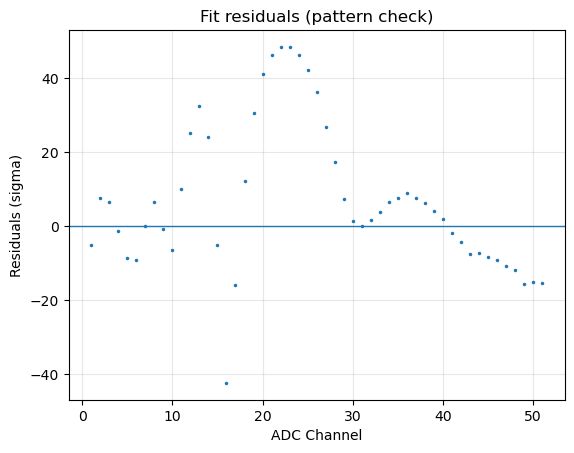

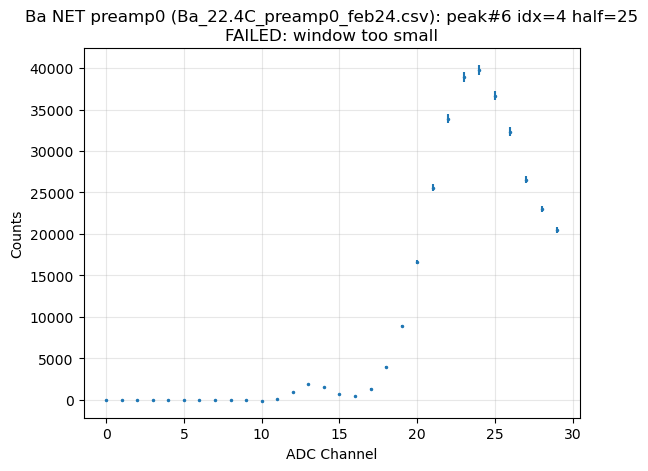

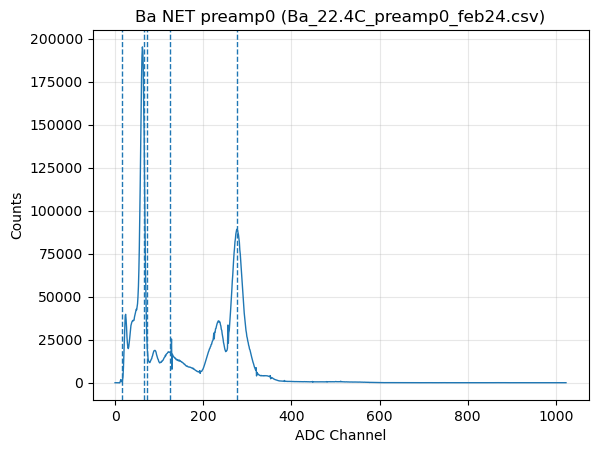

/tmp/ipykernel_5759/171756619.py:15: OptimizeWarning: Covariance of the parameters could not be estimated
  popt0, _ = curve_fit(cal_linear, ch, E)


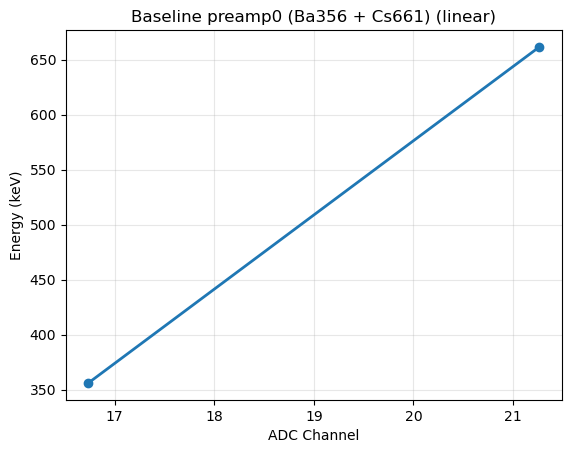

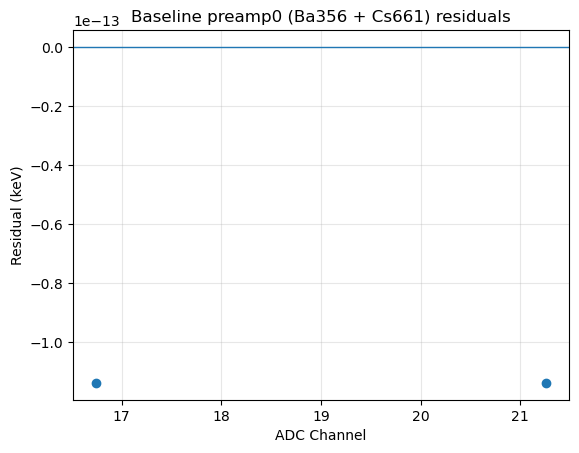

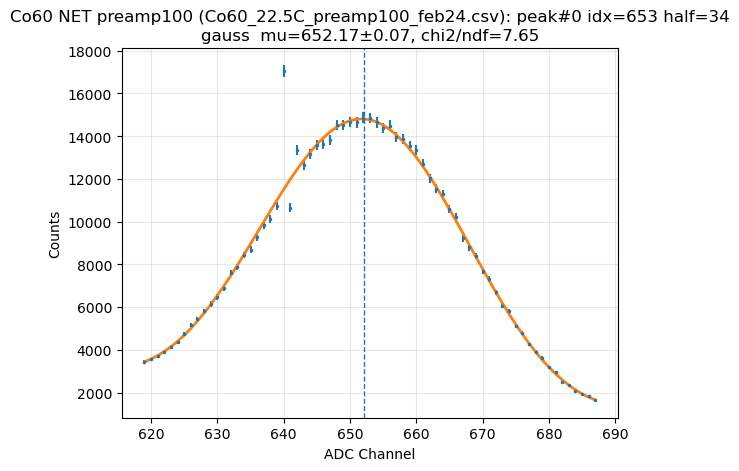

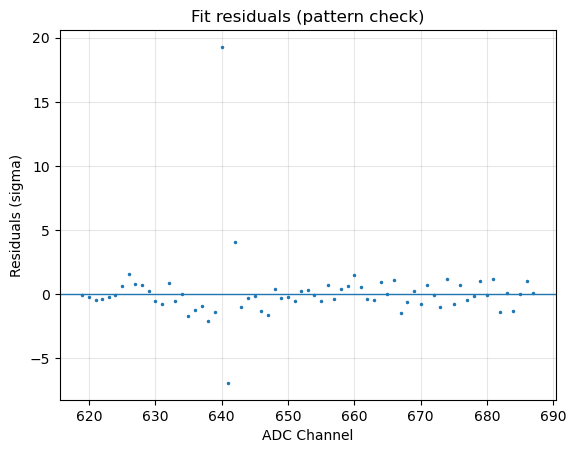

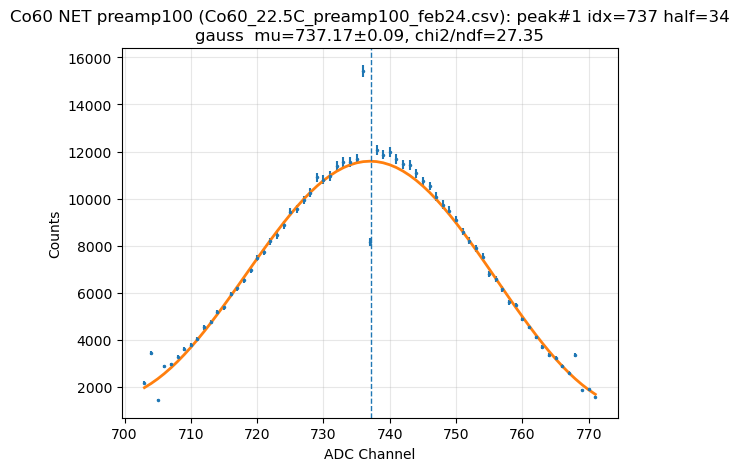

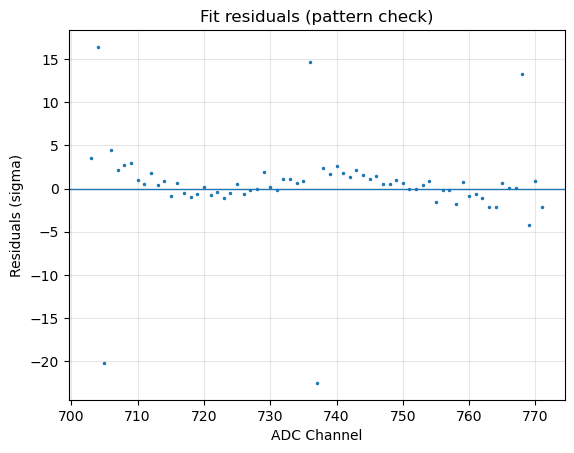

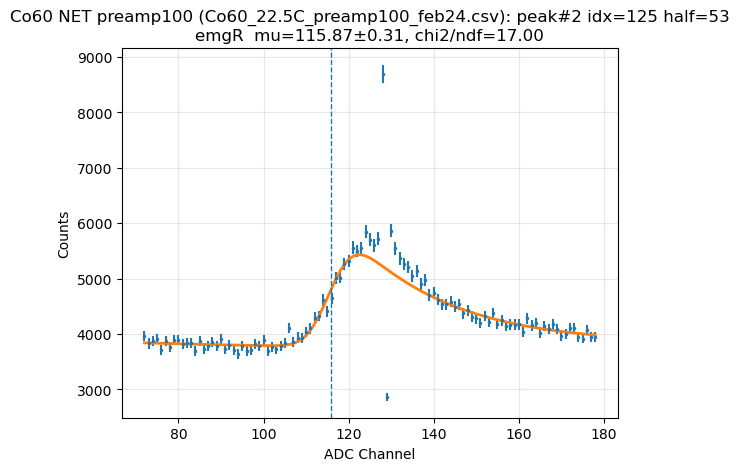

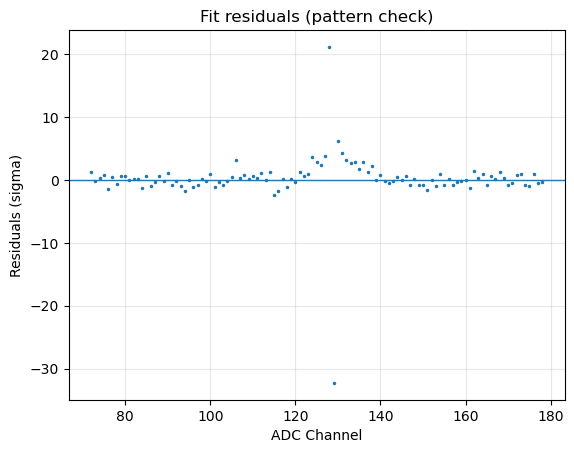

/tmp/ipykernel_5759/379950077.py:23: RuntimeWarning: overflow encountered in exp
  return 0.5*A*lam*np.exp(0.5*(lam*sig)**2 - lam*(x-mu)) * erfc(arg)
/tmp/ipykernel_5759/379950077.py:23: RuntimeWarning: overflow encountered in multiply
  return 0.5*A*lam*np.exp(0.5*(lam*sig)**2 - lam*(x-mu)) * erfc(arg)
/tmp/ipykernel_5759/379950077.py:23: RuntimeWarning: invalid value encountered in multiply
  return 0.5*A*lam*np.exp(0.5*(lam*sig)**2 - lam*(x-mu)) * erfc(arg)


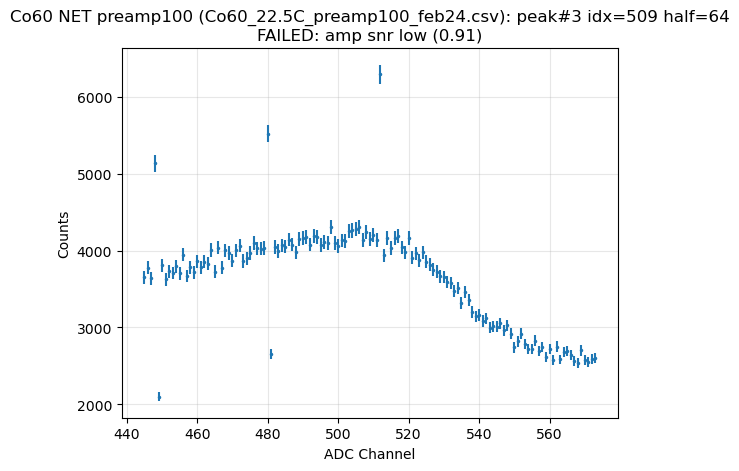

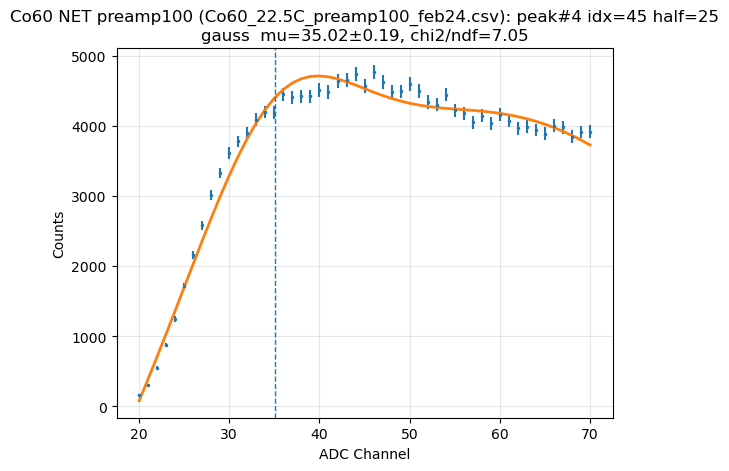

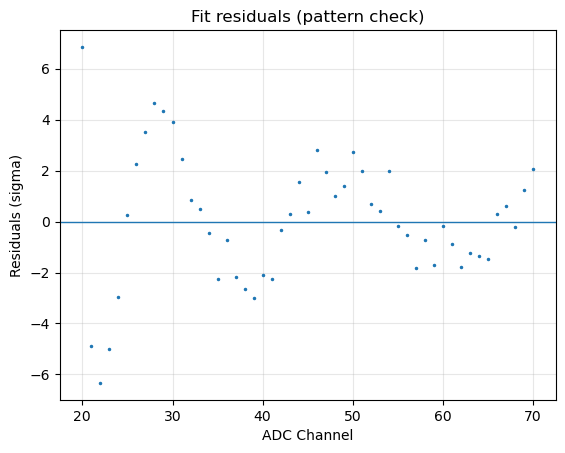

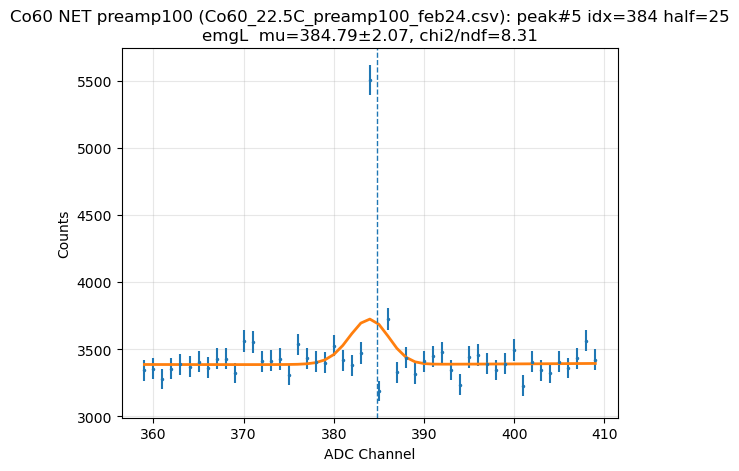

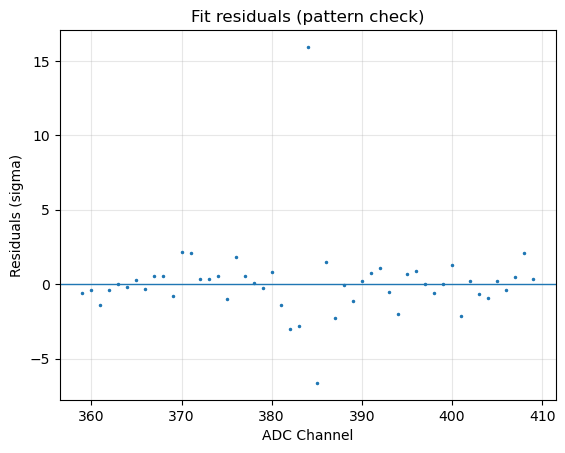

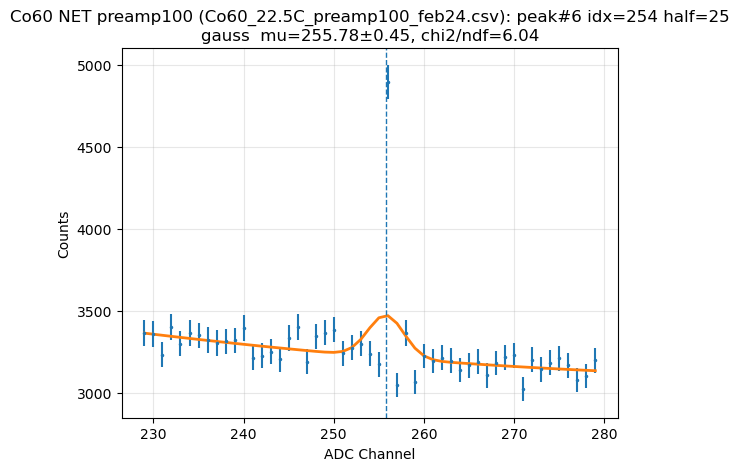

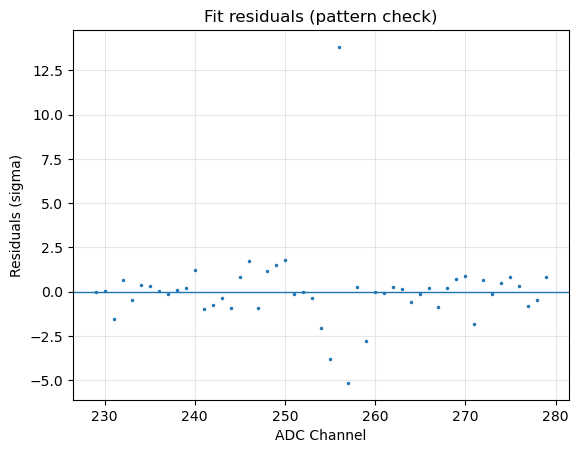

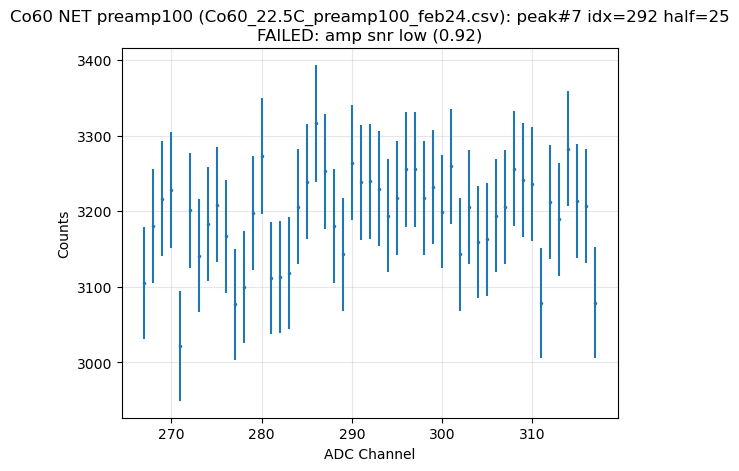

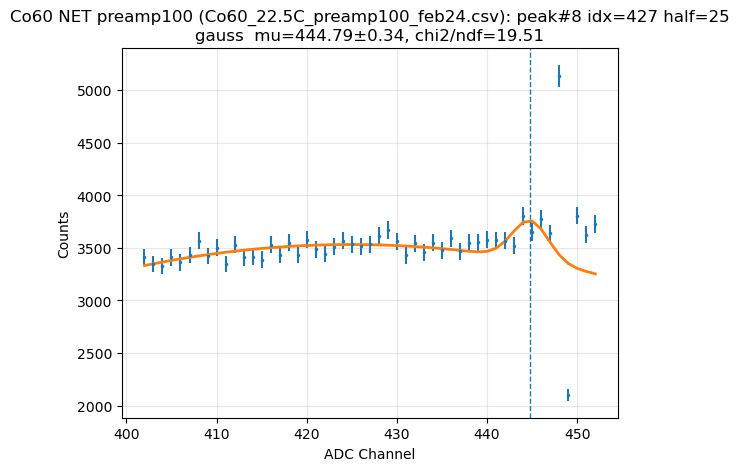

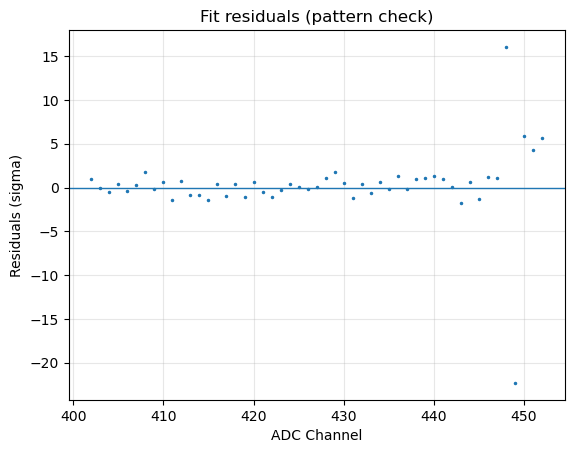

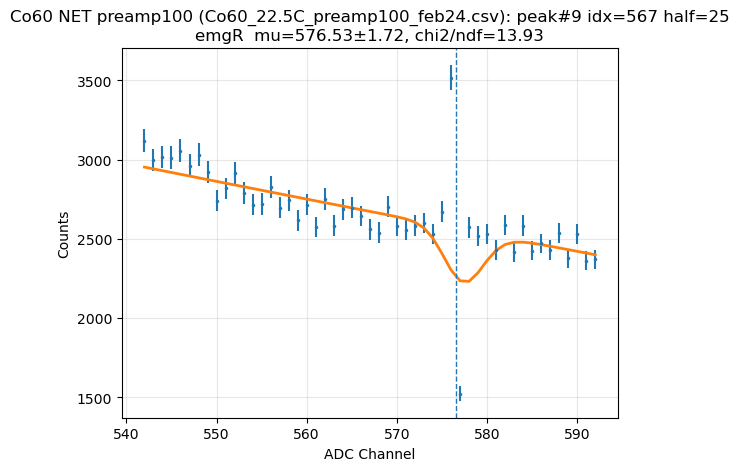

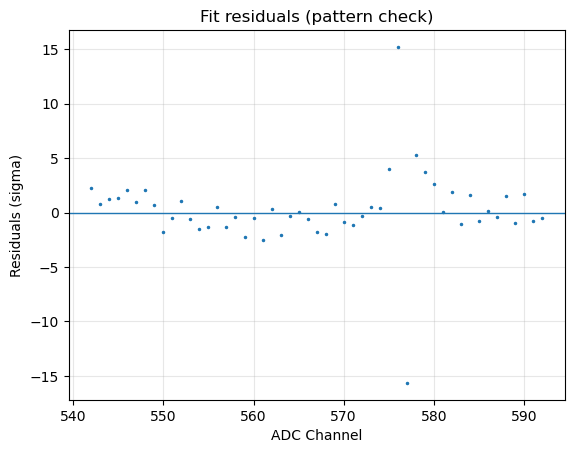

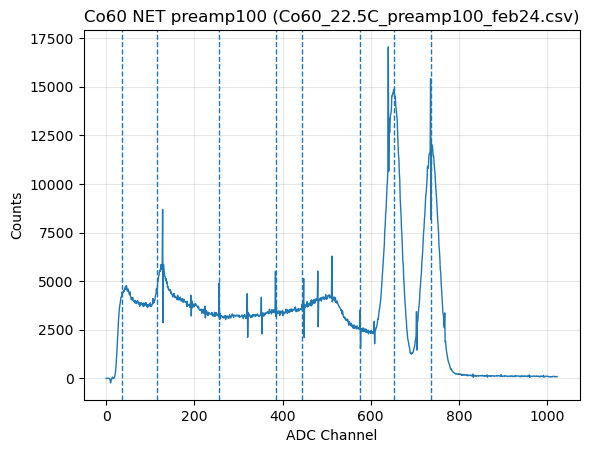

/tmp/ipykernel_5759/171756619.py:15: OptimizeWarning: Covariance of the parameters could not be estimated
  popt0, _ = curve_fit(cal_linear, ch, E)


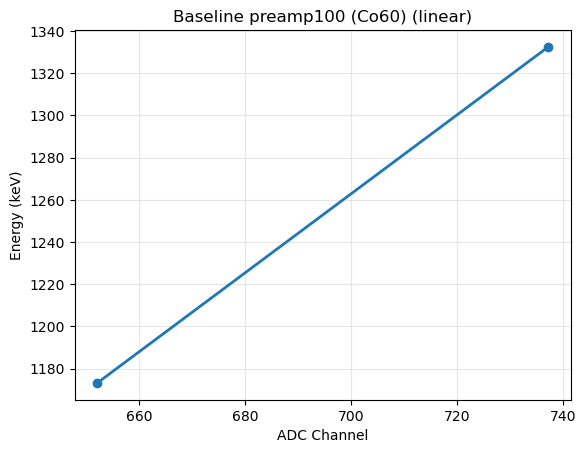

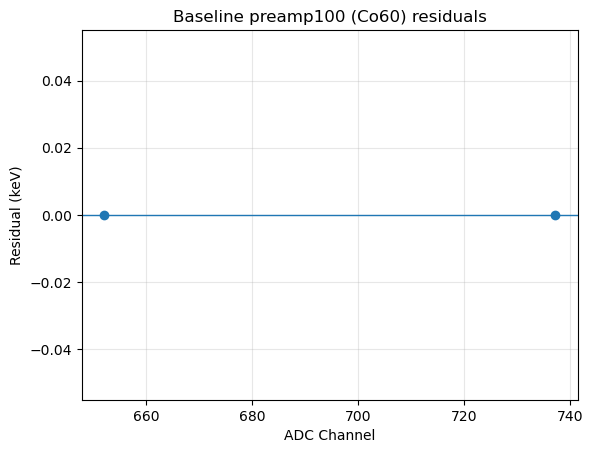


BASELINE
 preamp0: [  67.50136218 -773.74231233] Cs661 ch: 21.2647458646625
 preamp100: [  1.87373078 -48.76368686] Co60 ch: 652.170363362574 737.1697673749128

DAY 2026-02-26
 cs_path: processed_data/calibration/daily/Cs_22.4C_preamp0_feb26.csv
 co60_path: processed_data/calibration/daily/Co60_22.4C_preamp100_feb26.csv


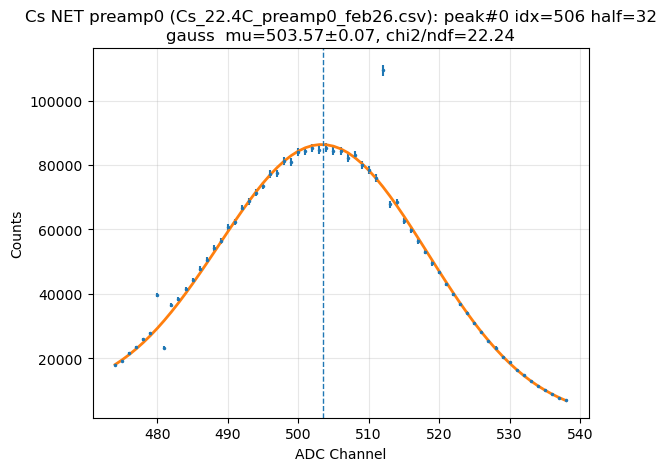

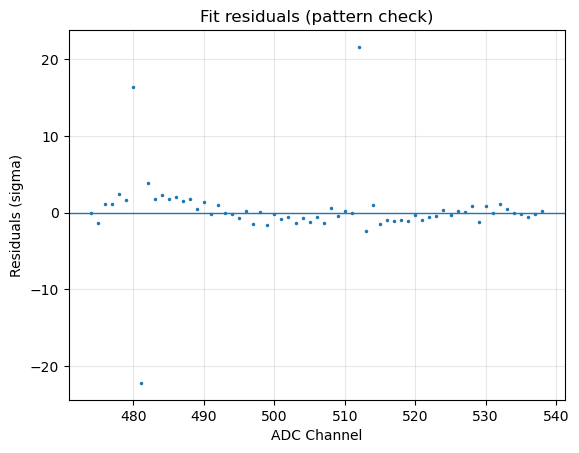

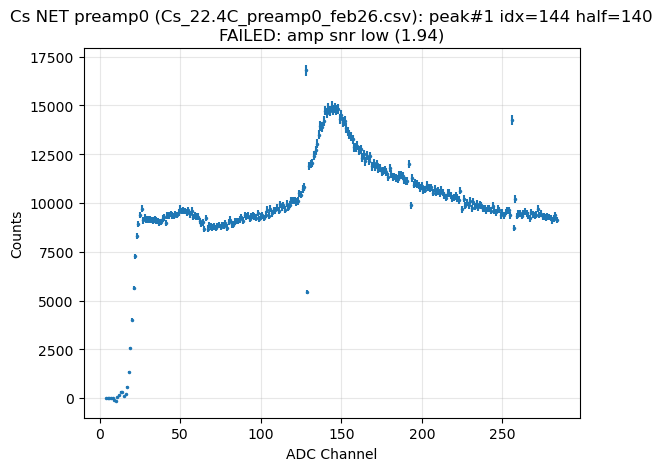

/tmp/ipykernel_5759/379950077.py:23: RuntimeWarning: overflow encountered in exp
  return 0.5*A*lam*np.exp(0.5*(lam*sig)**2 - lam*(x-mu)) * erfc(arg)
/tmp/ipykernel_5759/379950077.py:23: RuntimeWarning: invalid value encountered in multiply
  return 0.5*A*lam*np.exp(0.5*(lam*sig)**2 - lam*(x-mu)) * erfc(arg)


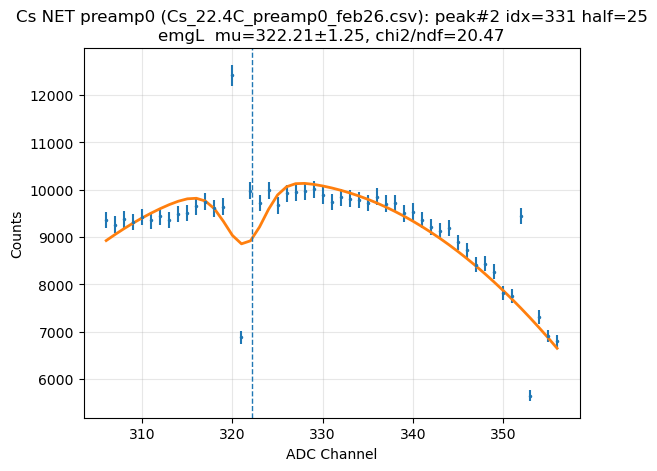

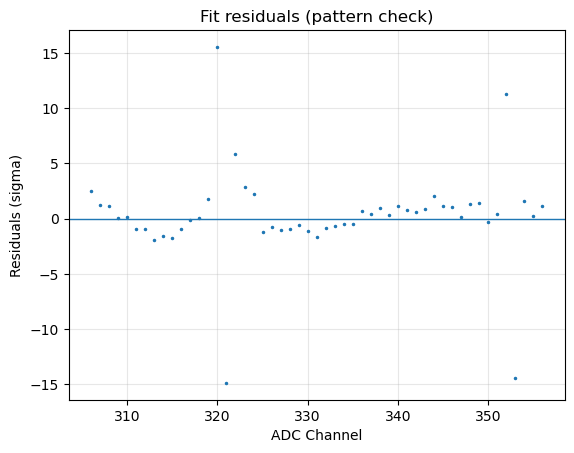

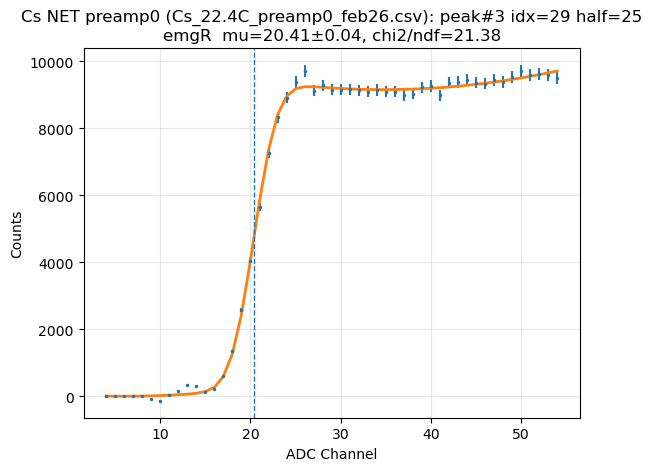

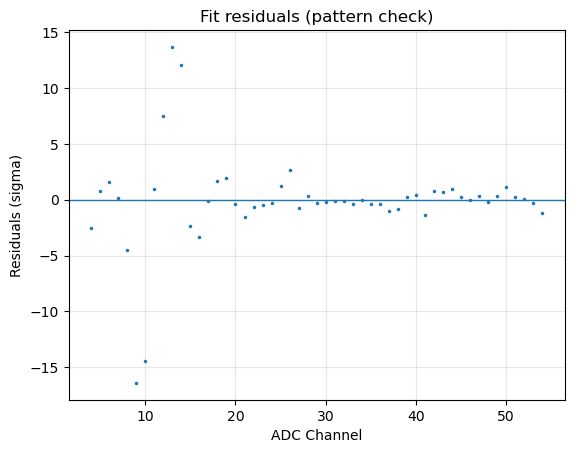

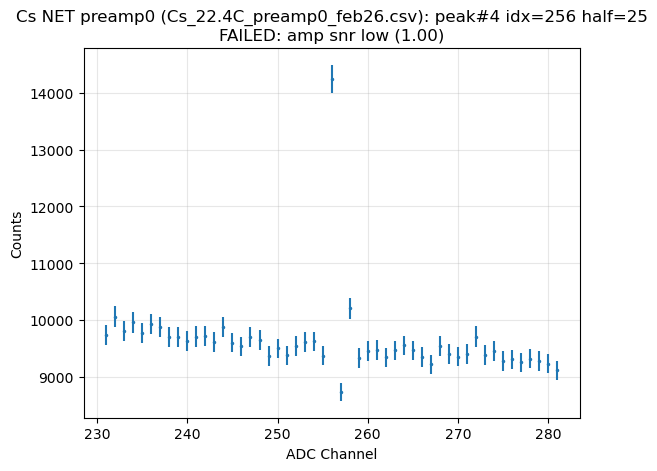

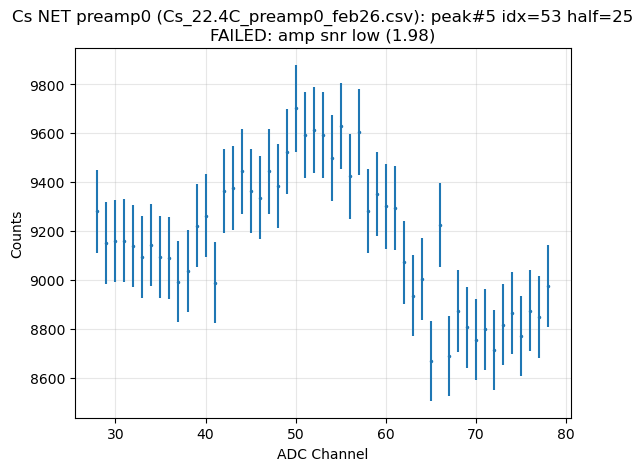

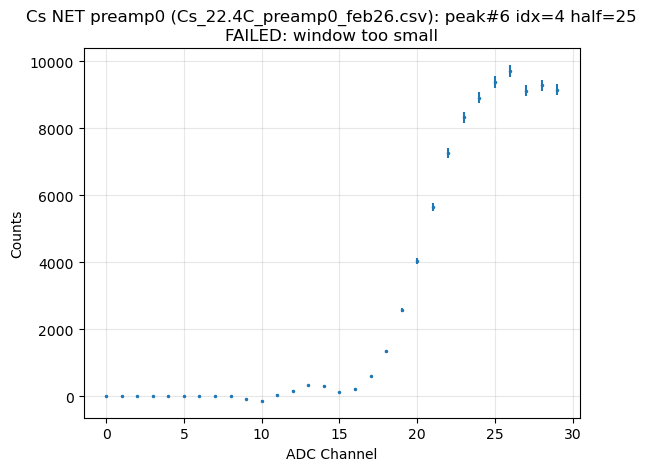

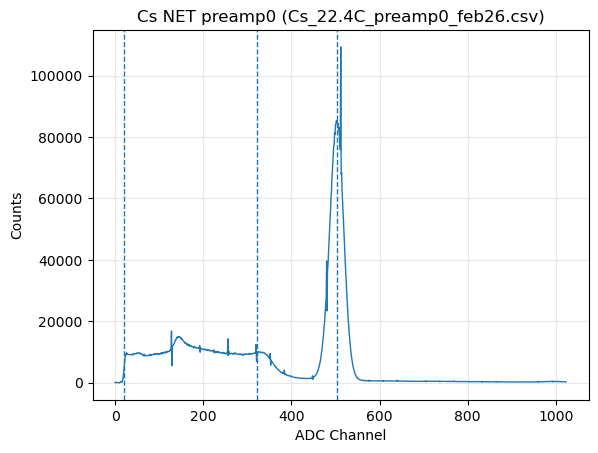

 preamp0 drift: baseline=21.26, today=20.41, delta=0.85


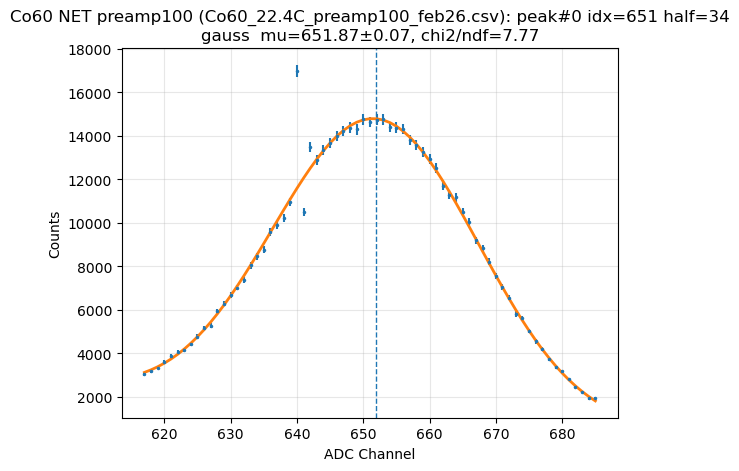

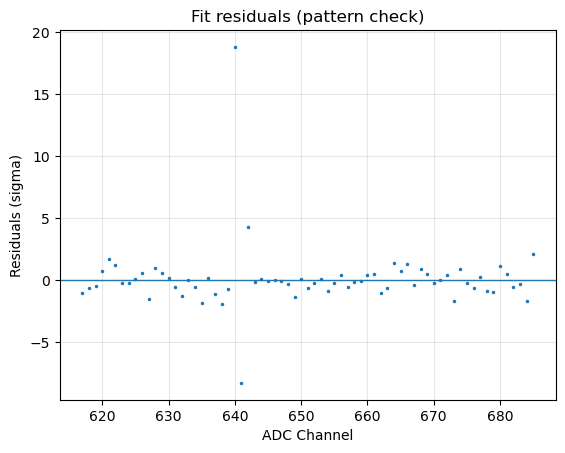

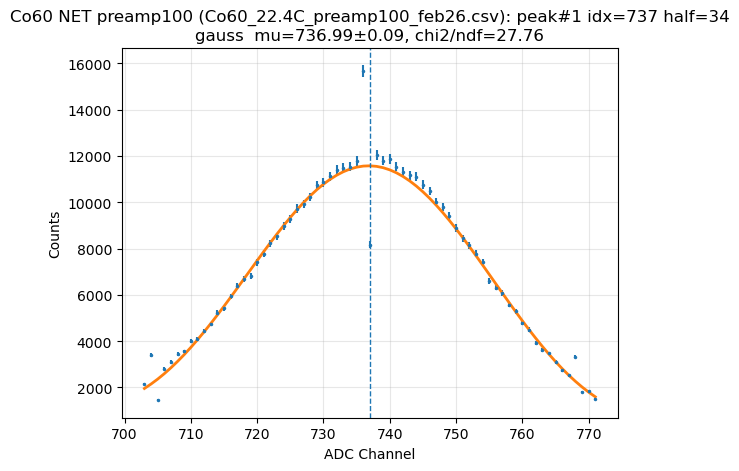

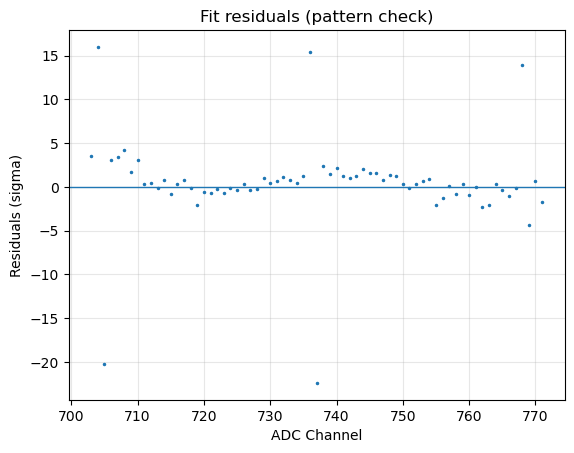

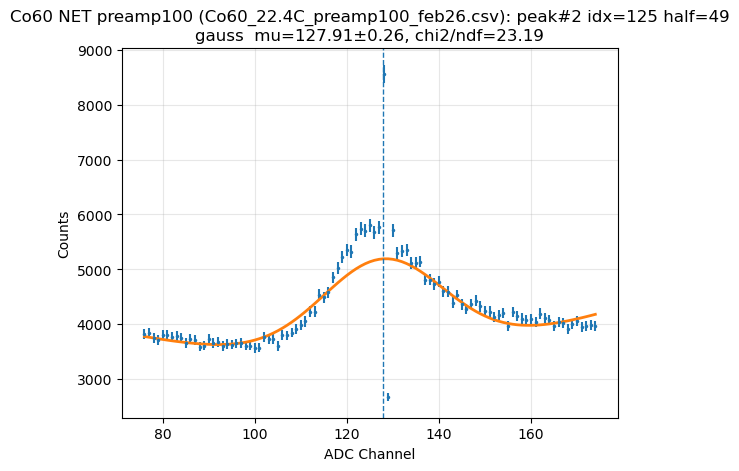

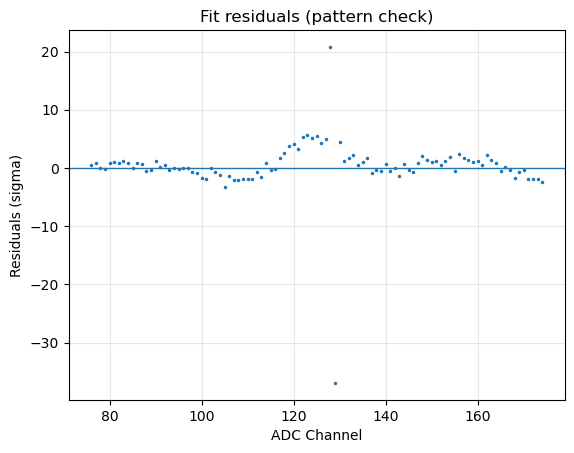

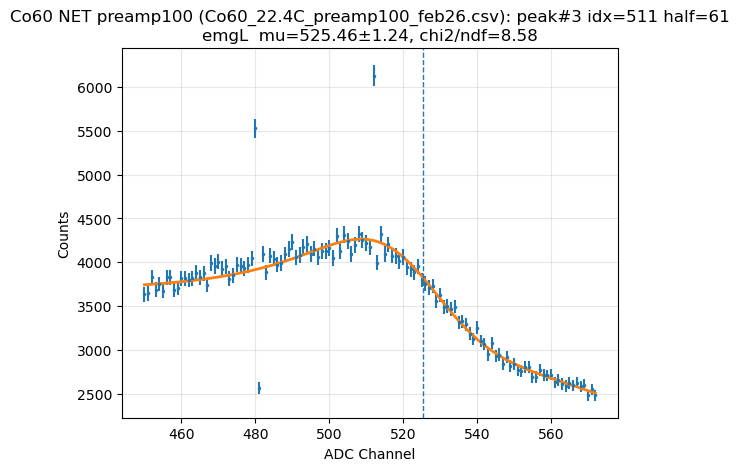

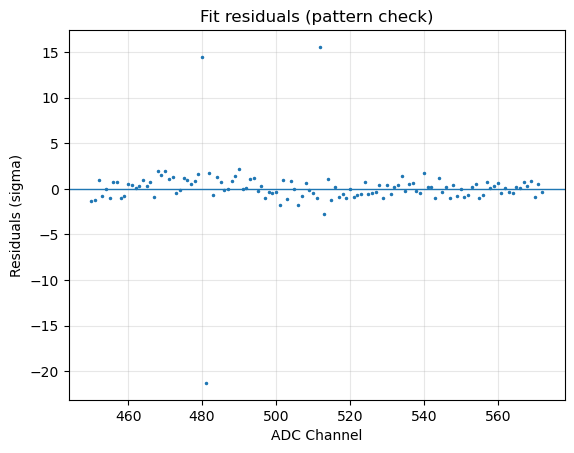

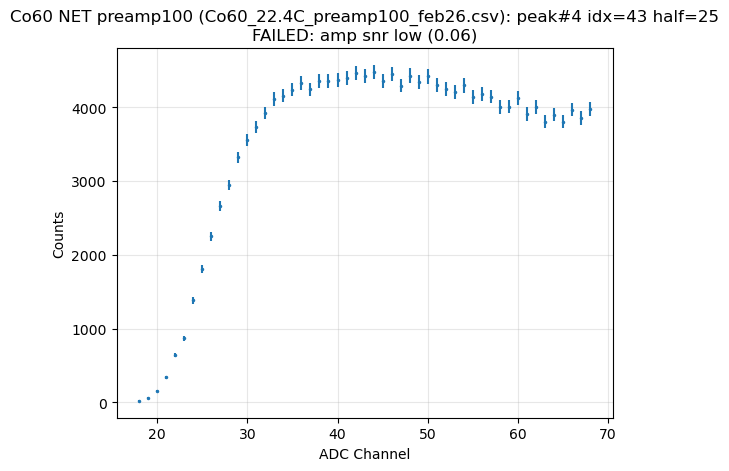

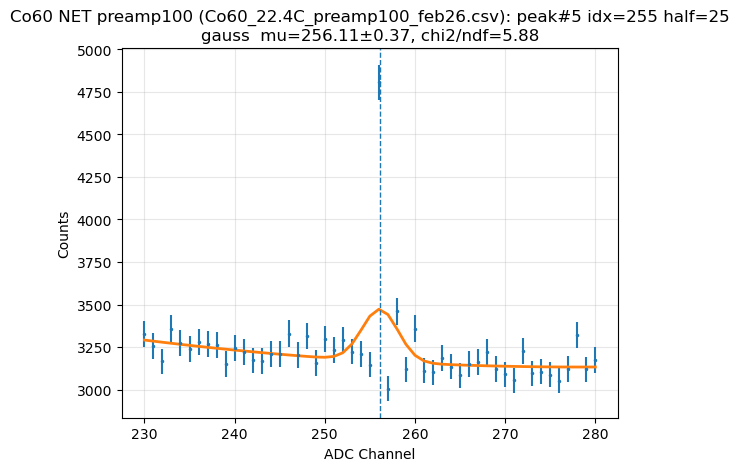

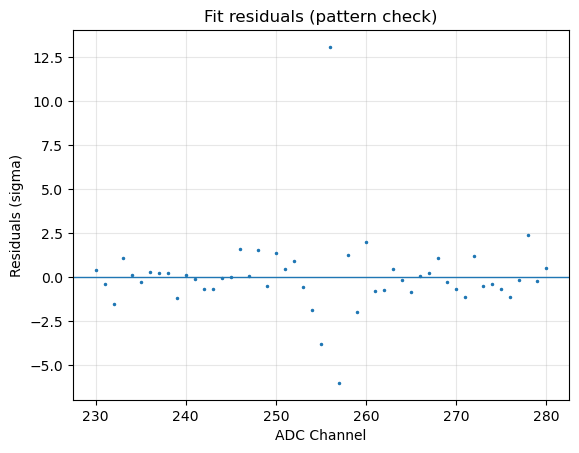

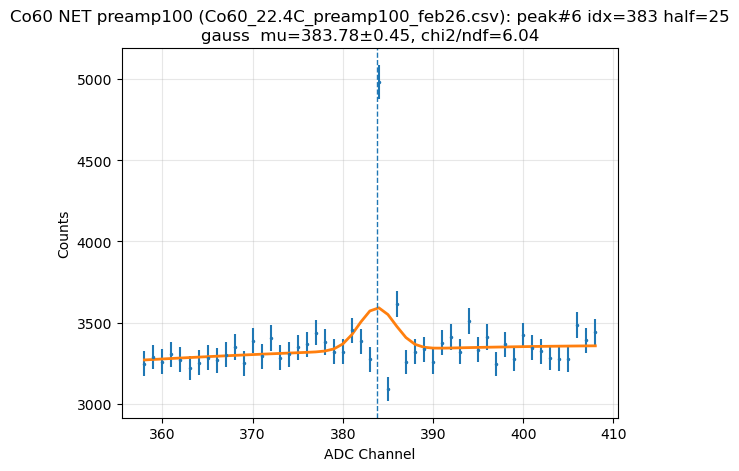

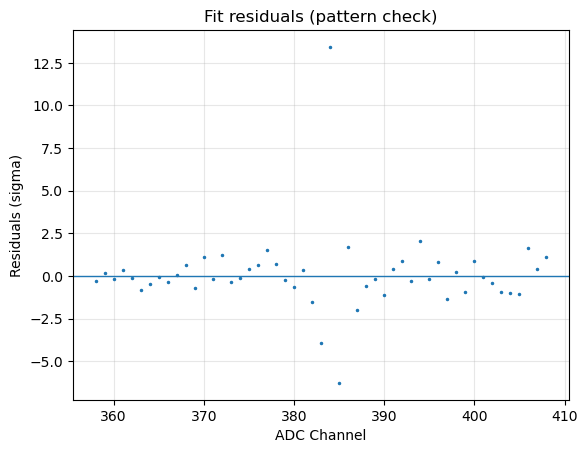

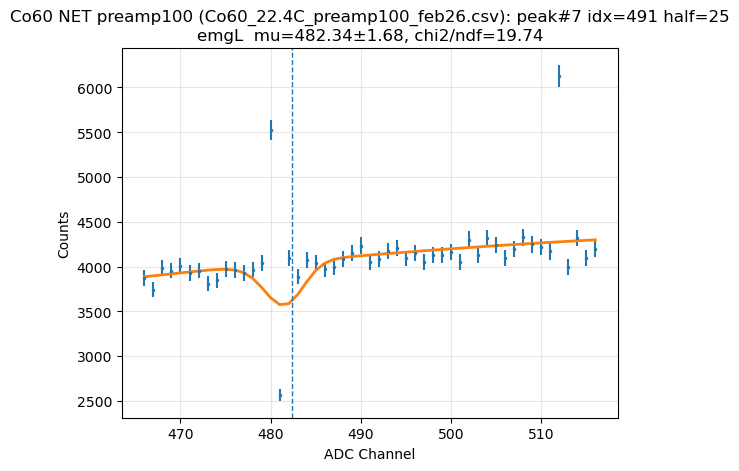

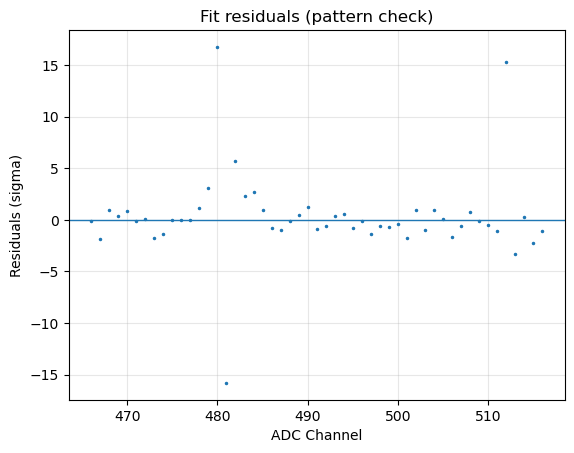

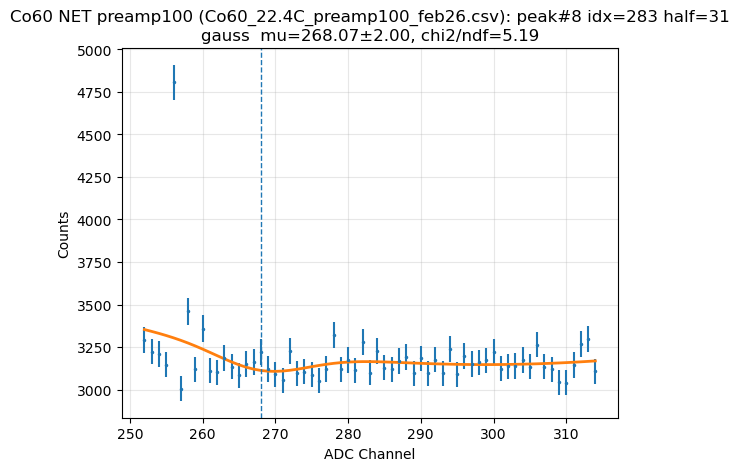

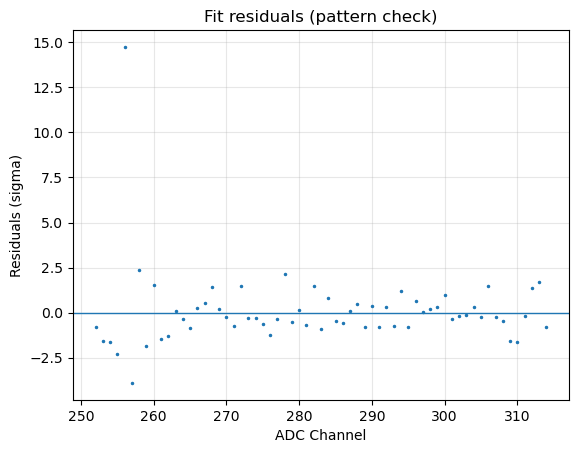

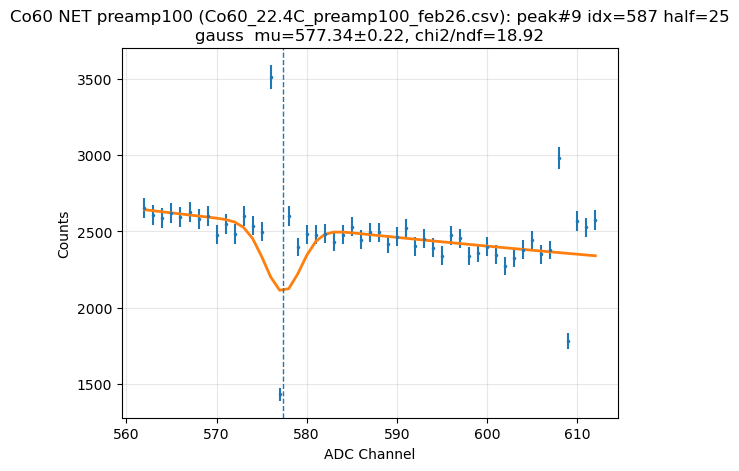

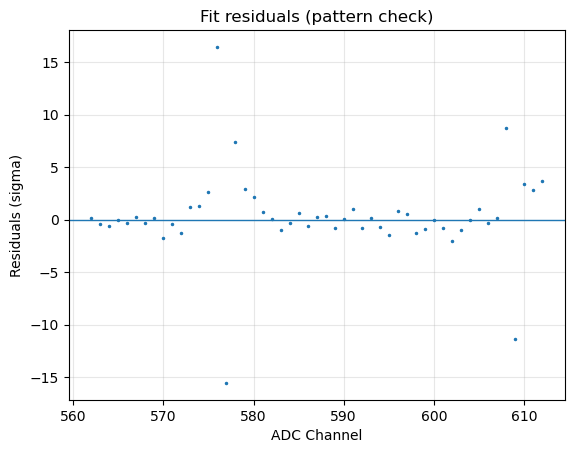

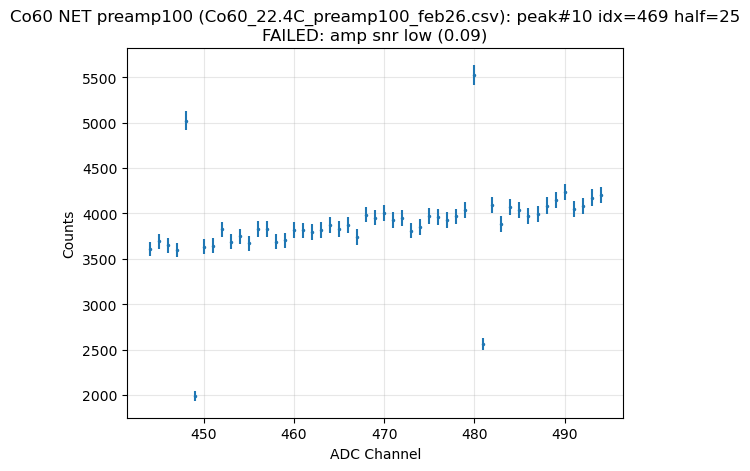

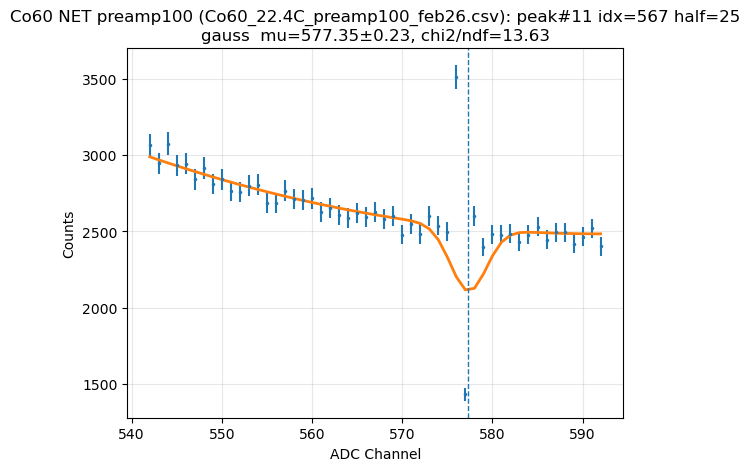

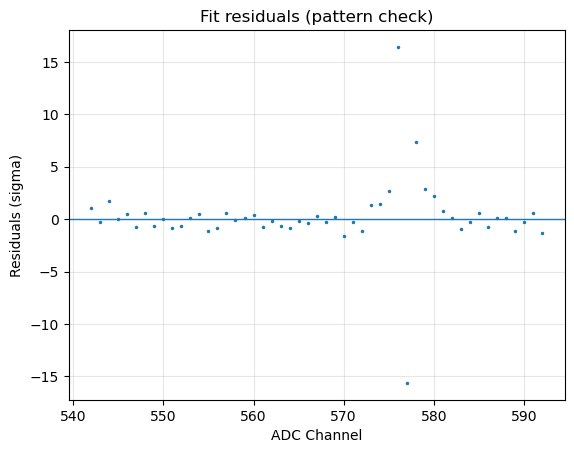

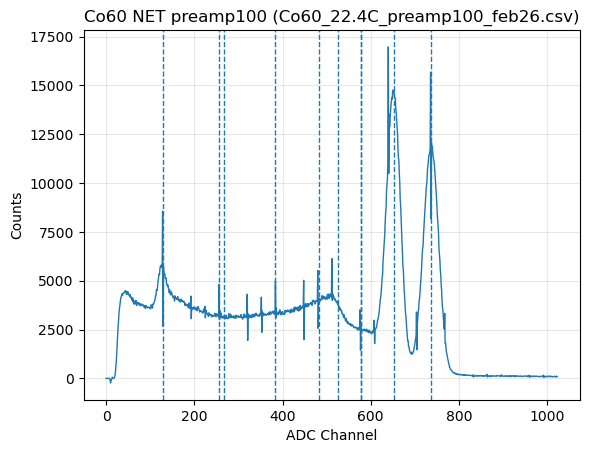

 preamp100 drift: alpha=0.672376, beta=298.867


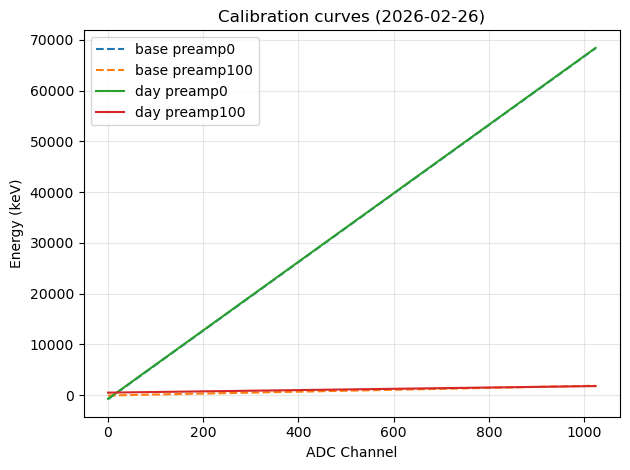

Saved: processed_data/calibration_curves/calcurves_2026-02-26.png

DAY 2026-03-03
 cs_path: processed_data/calibration/daily/Cs_22.0C_preamp0_mar3.csv
 co60_path: processed_data/calibration/daily/Co60_22.5C_preamp100_mar3.csv


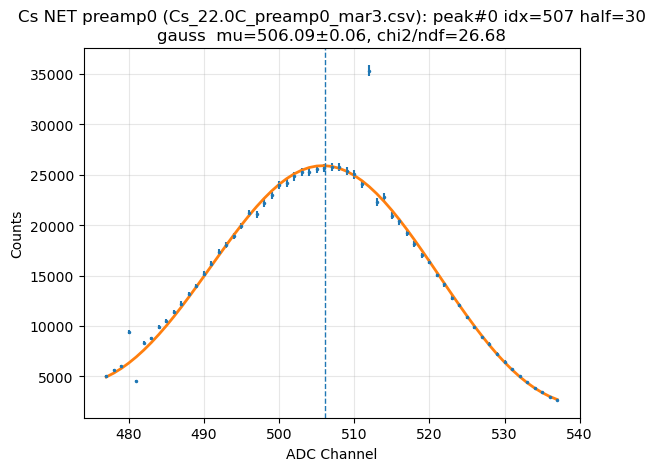

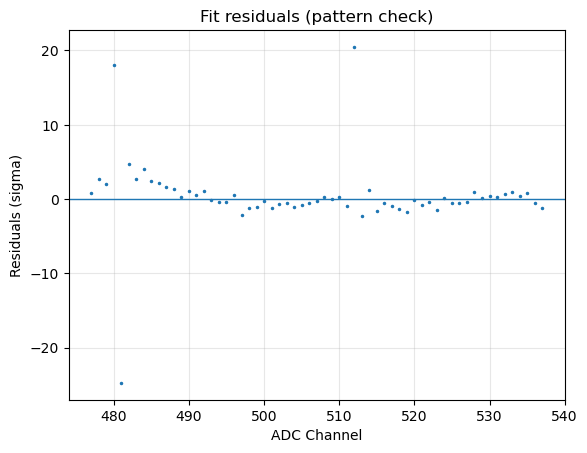

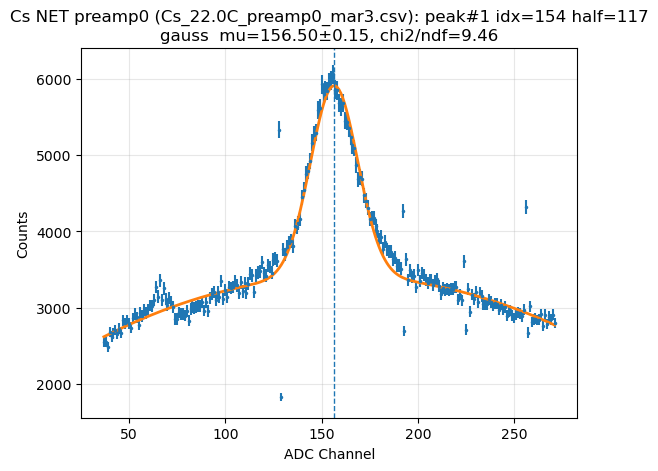

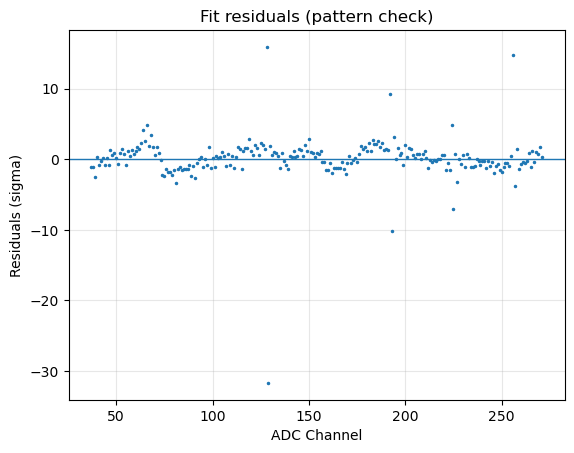

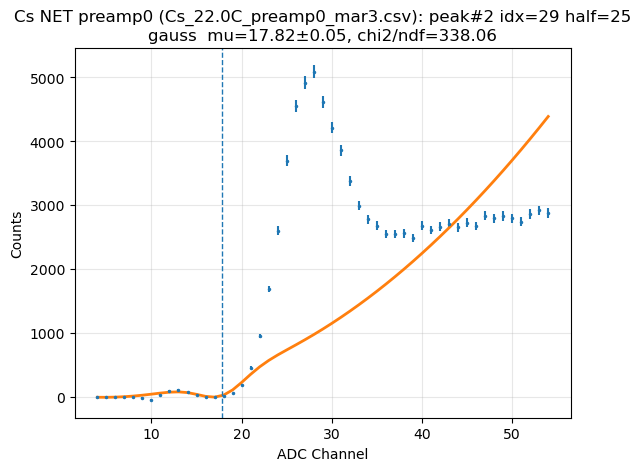

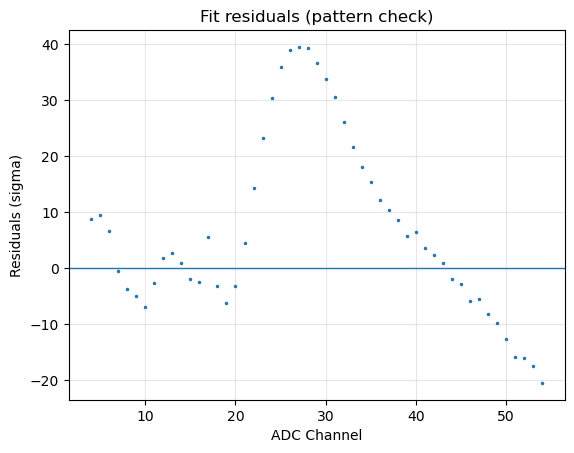

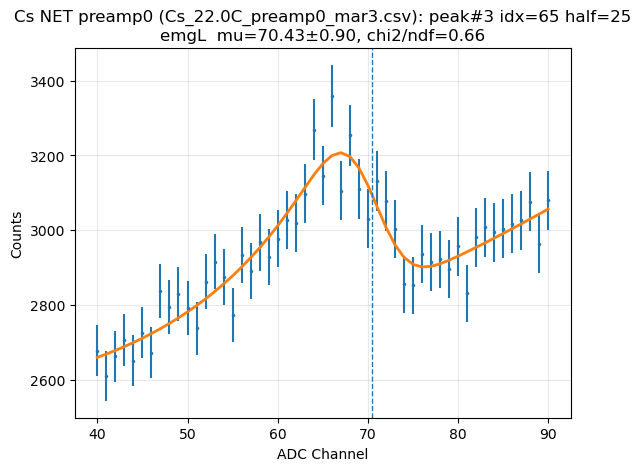

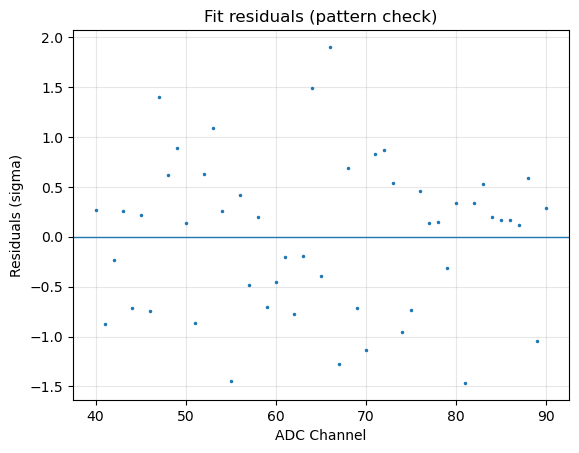

/tmp/ipykernel_5759/379950077.py:23: RuntimeWarning: overflow encountered in exp
  return 0.5*A*lam*np.exp(0.5*(lam*sig)**2 - lam*(x-mu)) * erfc(arg)
/tmp/ipykernel_5759/379950077.py:23: RuntimeWarning: invalid value encountered in multiply
  return 0.5*A*lam*np.exp(0.5*(lam*sig)**2 - lam*(x-mu)) * erfc(arg)


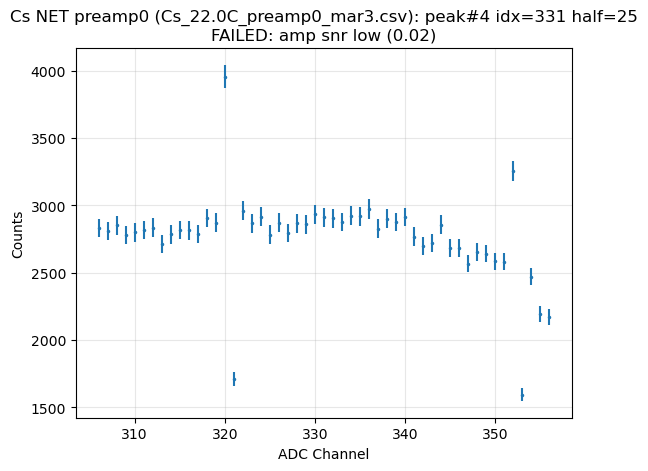

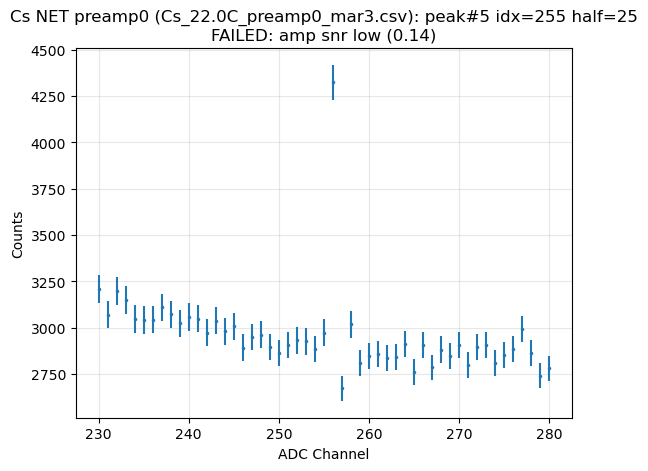

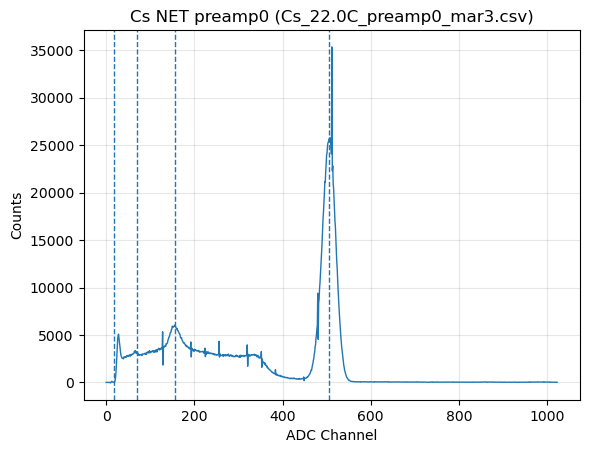

 preamp0 drift: baseline=21.26, today=506.09, delta=-484.82


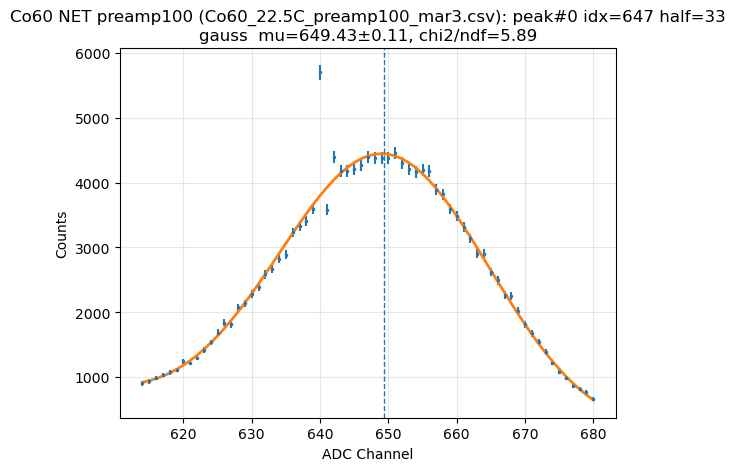

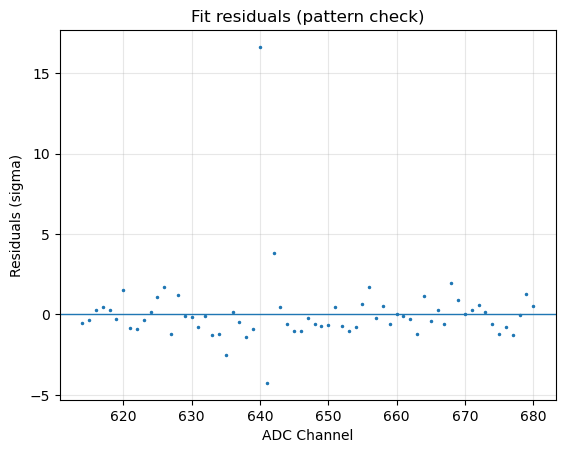

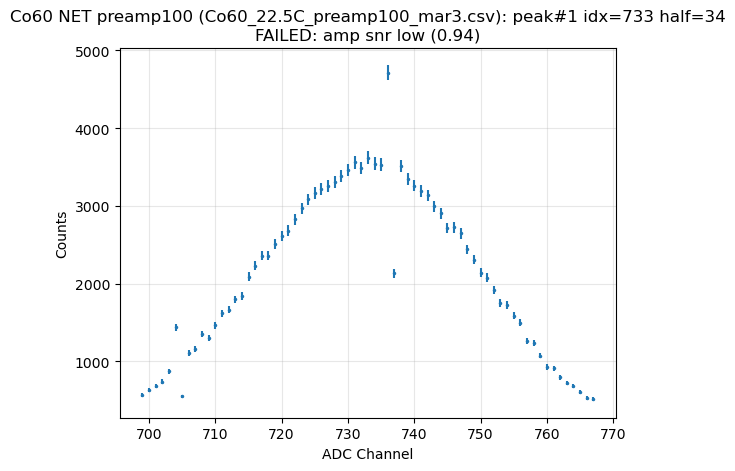

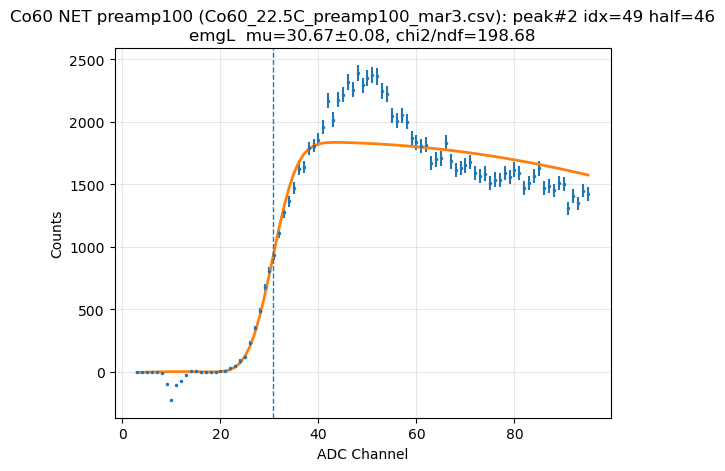

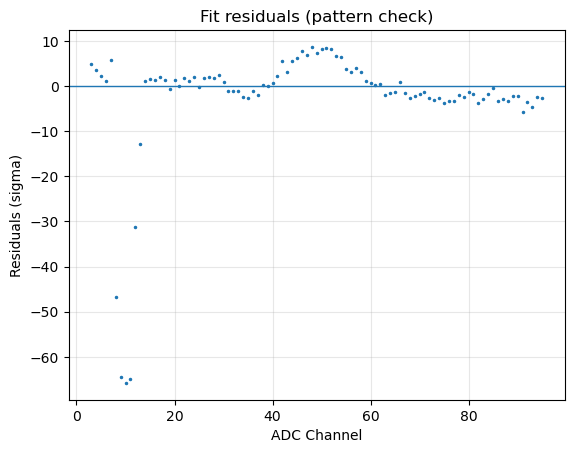

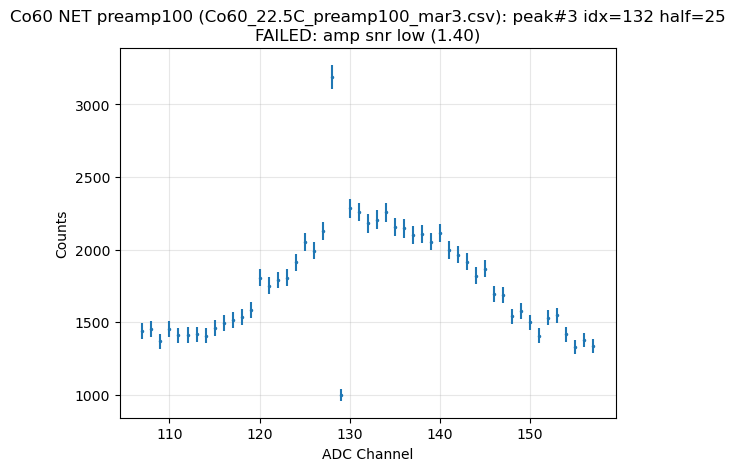

/tmp/ipykernel_5759/379950077.py:23: RuntimeWarning: overflow encountered in exp
  return 0.5*A*lam*np.exp(0.5*(lam*sig)**2 - lam*(x-mu)) * erfc(arg)
/tmp/ipykernel_5759/379950077.py:23: RuntimeWarning: invalid value encountered in multiply
  return 0.5*A*lam*np.exp(0.5*(lam*sig)**2 - lam*(x-mu)) * erfc(arg)
/tmp/ipykernel_5759/379950077.py:23: RuntimeWarning: overflow encountered in multiply
  return 0.5*A*lam*np.exp(0.5*(lam*sig)**2 - lam*(x-mu)) * erfc(arg)


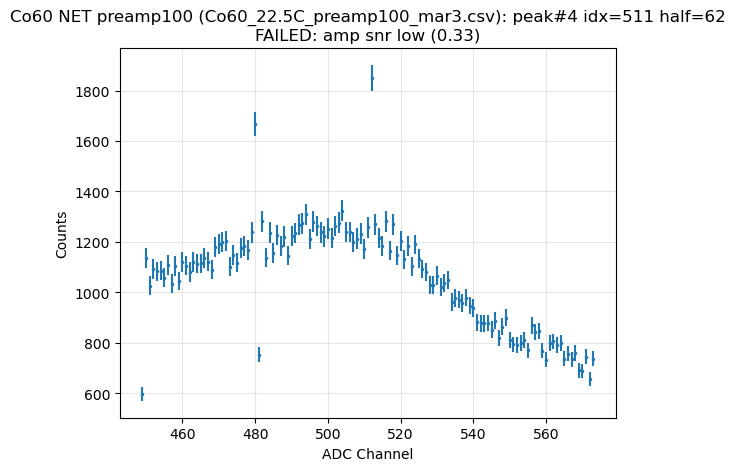

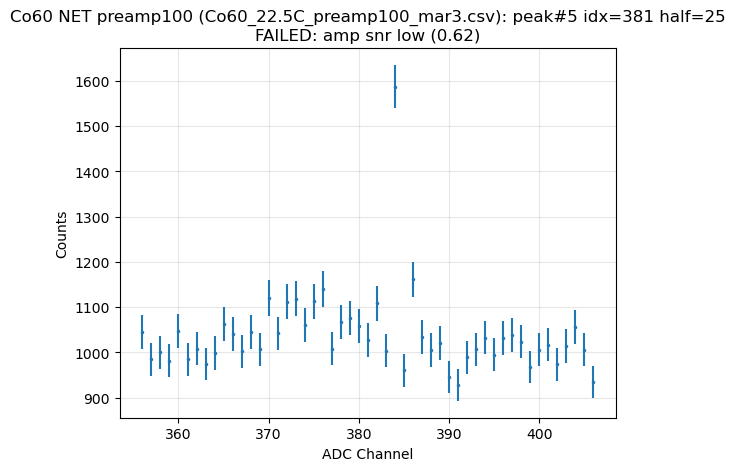

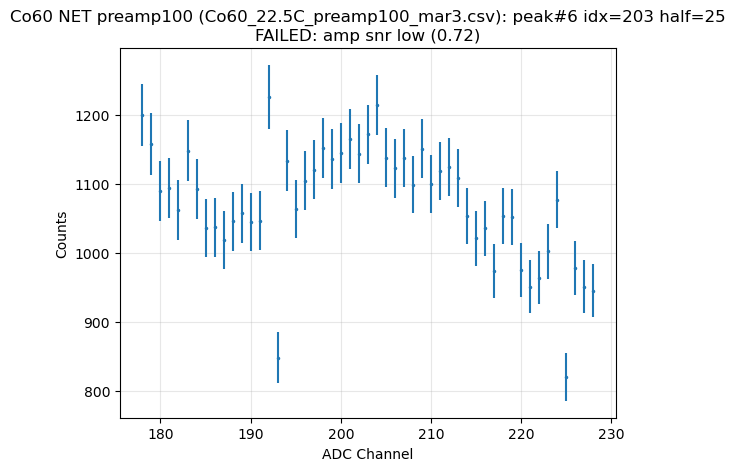

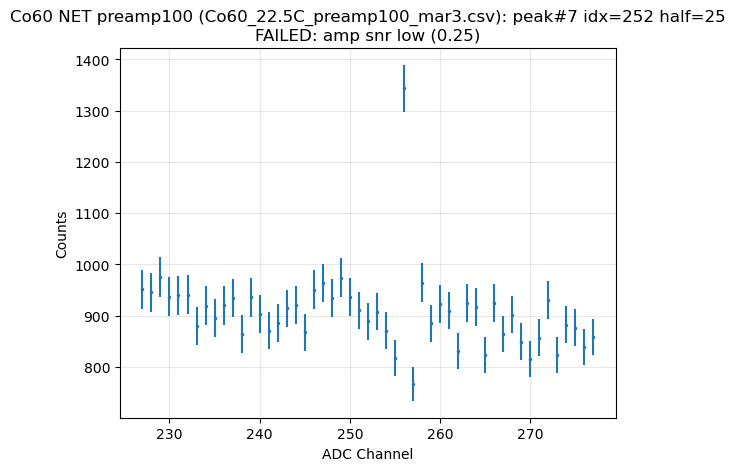

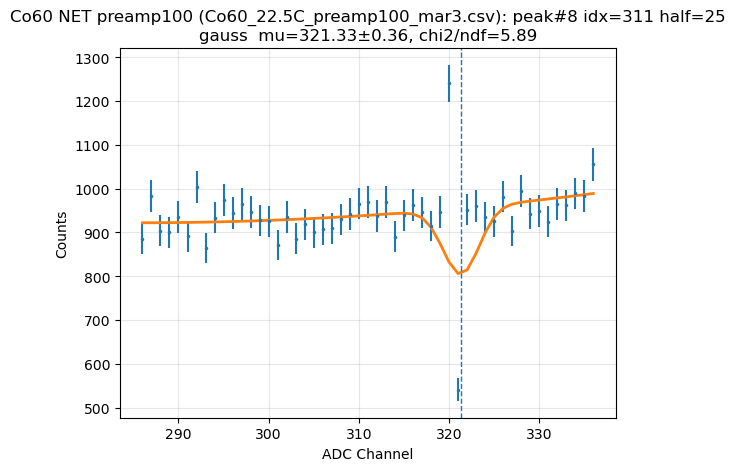

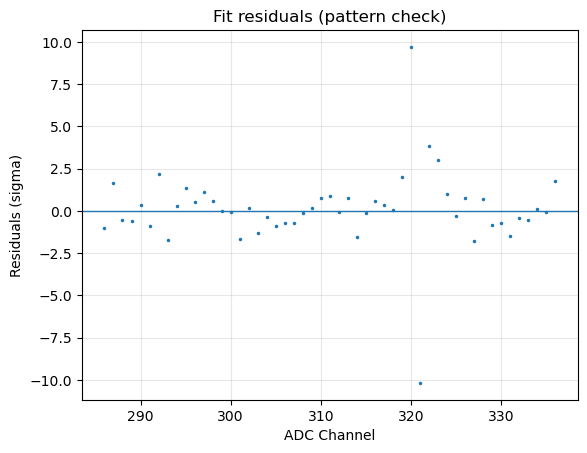

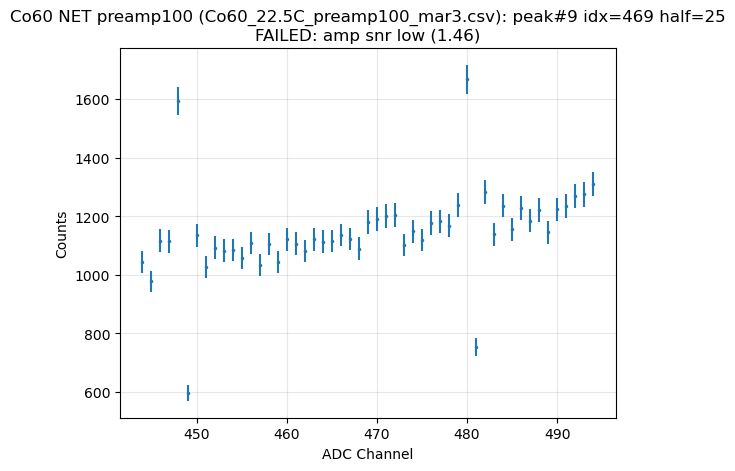

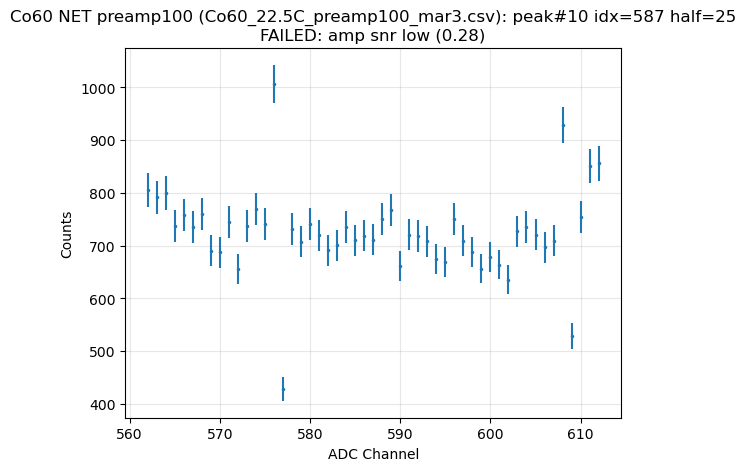

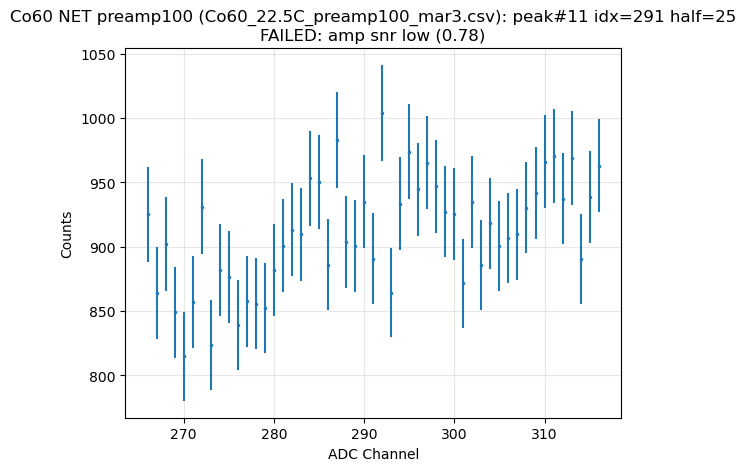

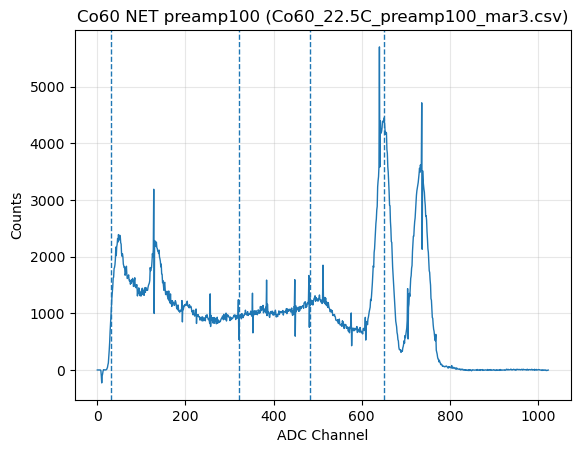

 preamp100 drift: alpha=0.137370, beta=647.958


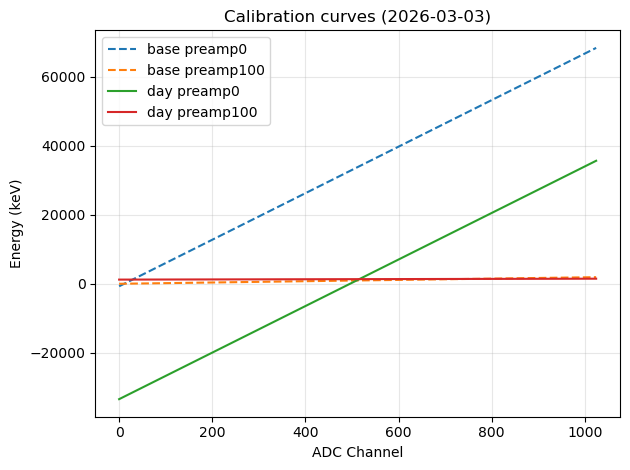

Saved: processed_data/calibration_curves/calcurves_2026-03-03.png

Saved summary: processed_data/calibration_curves/daily_calibration_params.csv


,day,cs_path,co60_path,cal0_m,cal0_b,cal100_m,cal100_b
0,2026-02-26,processed_data/calibration/daily/Cs_22.4C_prea...,processed_data/calibration/daily/Co60_22.4C_pr...,67.501362,-716.343386,1.259852,511.232340
1,2026-03-03,processed_data/calibration/daily/Cs_22.0C_prea...,processed_data/calibration/daily/Co60_22.5C_pr...,67.501362,-33500.078941,0.257394,1165.334866


In [13]:
# -----------------------------
# RUN
# -----------------------------
all_csvs = list_csvs(ROOT_CAL)
print(f"Found {len(all_csvs)} CSVs under {ROOT_CAL}")

baseline_cs = select_isotope(all_csvs, date_folder="feb_24", preamp_folder="preamp_0", isotope="Cs")
baseline_ba = select_isotope(all_csvs, date_folder="feb_24", preamp_folder="preamp_0", isotope="Ba")
baseline_co60 = select_isotope(all_csvs, date_folder="feb_24", preamp_folder="preamp_100", isotope="Co60")

if baseline_cs is None or baseline_ba is None or baseline_co60 is None:
    raise RuntimeError("Missing baseline Cs/Ba/Co60. Check processed_data/calibration tree and filenames.")

bg_path = BG_DEFAULT if (BG_DEFAULT is not None and BG_DEFAULT.exists()) else None
print("bg_path:", bg_path)

cal0_base, info0 = build_baseline_preamp0(baseline_cs, baseline_ba, bg_path=bg_path)
cal100_base, info100 = build_baseline_preamp100(baseline_co60, bg_path=bg_path)

base_cs_ch = float(info0["cs_661_candidate"].mu)
base_co1173_ch = float(info100["co60_doublet"][0].mu)
base_co1332_ch = float(info100["co60_doublet"][1].mu)

print("\nBASELINE")
print(" preamp0:", cal0_base.params, "Cs661 ch:", base_cs_ch)
print(" preamp100:", cal100_base.params, "Co60 ch:", base_co1173_ch, base_co1332_ch)

groups = group_daily_files(all_csvs)
daily_rows = []

for day, by_preamp in sorted(groups.items()):
    if day == "unknown-day":
        continue

    cs_path = by_preamp.get(0, {}).get("cs")
    co60_path = by_preamp.get(100, {}).get("co60")
    if cs_path is None and co60_path is None:
        continue

    print("\nDAY", day)
    print(" cs_path:", cs_path)
    print(" co60_path:", co60_path)

    cal0_day = None
    cal100_day = None

    # preamp0: drift from Cs661 centroid (offset)
    if cs_path is not None:
        cs = read_spectrum_csv(cs_path)
        if bg_path is not None:
            bg = read_spectrum_csv(bg_path)
            net = subtract_background_counts(cs, bg)
            x, y, yerr = net.channel, net.net_counts, net.net_sigma
            allow_neg = True
            label = f"Cs NET preamp0 ({cs_path.name})"
        else:
            x, y, yerr = spectrum_with_errors(cs)
            allow_neg = False
            label = f"Cs RAW preamp0 ({cs_path.name})"

        peaks = discover_peak_list(x, y, yerr, CFG, allow_negative_amp=allow_neg, label=label)
        plot_spectrum(x, y, title=label, peaks=peaks)

        if peaks:
            cs661_today = max(peaks, key=lambda p: abs(p.amp))
            delta = base_cs_ch - float(cs661_today.mu)
            cal0_day = drifted_calibration_from_baseline_linear(cal0_base, alpha=1.0, beta=delta)
            print(f" preamp0 drift: baseline={base_cs_ch:.2f}, today={cs661_today.mu:.2f}, delta={delta:.2f}")
        else:
            print(" WARNING: no Cs peaks accepted; skipping preamp0 day cal.")

    # preamp100: drift from Co60 doublet (scale+offset)
    if co60_path is not None:
        co60 = read_spectrum_csv(co60_path)
        if bg_path is not None:
            bg = read_spectrum_csv(bg_path)
            net = subtract_background_counts(co60, bg)
            x, y, yerr = net.channel, net.net_counts, net.net_sigma
            allow_neg = True
            label = f"Co60 NET preamp100 ({co60_path.name})"
        else:
            x, y, yerr = spectrum_with_errors(co60)
            allow_neg = False
            label = f"Co60 RAW preamp100 ({co60_path.name})"

        peaks = discover_peak_list(x, y, yerr, CFG, allow_negative_amp=allow_neg, label=label)
        plot_spectrum(x, y, title=label, peaks=peaks)

        pair = identify_co60_doublet(peaks)
        if pair is not None:
            co1173_today, co1332_today = pair
            alpha, beta = linear_map_from_two_points(float(co1173_today.mu), base_co1173_ch,
                                                     float(co1332_today.mu), base_co1332_ch)
            cal100_day = drifted_calibration_from_baseline_linear(cal100_base, alpha=alpha, beta=beta)
            print(f" preamp100 drift: alpha={alpha:.6f}, beta={beta:.3f}")
        else:
            print(" WARNING: couldn't identify Co60 doublet; skipping preamp100 day cal.")

    plot_daily_calibration_day(day, cal0_day, cal100_day, cal0_base, cal100_base)

    daily_rows.append({
        "day": day,
        "cs_path": str(cs_path) if cs_path else "",
        "co60_path": str(co60_path) if co60_path else "",
        "cal0_m": float(cal0_day.params[0]) if cal0_day else np.nan,
        "cal0_b": float(cal0_day.params[1]) if cal0_day else np.nan,
        "cal100_m": float(cal100_day.params[0]) if cal100_day else np.nan,
        "cal100_b": float(cal100_day.params[1]) if cal100_day else np.nan,
    })

df = pd.DataFrame(daily_rows).sort_values("day")
out_csv = OUT_DIR / "daily_calibration_params.csv"
df.to_csv(out_csv, index=False)
print("\nSaved summary:", out_csv)
df
